# Bibliotekos

In [476]:
import pandas as pd
import numpy as np
import torch
torch.cuda.is_available()
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr
from skorch import NeuralNetRegressor
from skorch.callbacks import Checkpoint, EarlyStopping
from skorch.dataset import ValidSplit

from pyts.decomposition import SingularSpectrumAnalysis

from Lasso2 import select_features_lasso

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

from sklearn.base import BaseEstimator, RegressorMixin
from skorch import NeuralNetRegressor

from sklearn.metrics import make_scorer, root_mean_squared_error

# Duomenų paruošimas

In [477]:
data = pd.read_csv("../datasets_prep/dm_project_dataset.csv")

data['observationTime'] = pd.to_datetime(data['observationTime'])
data['month'] = data['observationTime'].dt.month
data['day_of_year'] = data['observationTime'].dt.dayofyear
data['day_of_week'] = data['observationTime'].dt.dayofweek

data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

lag_config = {
    'H2O_column_number_density': [1],
    'NO2_column_number_density': [1, 2, 3],
    'nmvoc': [1],
    'nh3': [1, 2, 11],
    'pm10': [1],
    'pans': [10],
    'dust': [1],
    'NO2': np.arange(1, 10, 1)
}

for feature, lags in lag_config.items():
    for lag in lags:
        data[f'{feature}_lag{lag}'] = data[feature].shift(lag)

# data['target'] = data['missforest_precipitation'].shift(-1)
data = data.dropna()

drop_names = [
    'observationTime',
    # 'absorbing_aerosol_index',
    # 'NO2_column_number_density',
    # 'stratospheric_NO2_column_number_density',
    # 'NO2_slant_column_number_density',
    # 'tropopause_pressure',
    # 'H2O_column_number_density',
    # 'BrO',
    # 'BrO_Error',
    # 'NO2',
    # 'NO2_Error',
    # 'O3',
    # 'O3_Error',
    # 'pm10',
    # 'pm2p5',
    # 'sia',
    # 'nmvoc',
    # 'dust',
    # 'nh3',
    # 'pans',
    # 'tp',
    # 't2m',
    # 'airTemperature',
    # 'seaLevelPressure',
    # 'relativeHumidity',
    # 'missforest_precipitation',
    # 'xgb_cloudCover',
    # 'feelsLikeTemperature_fixed',
    # 'windSpeed_fixed',
    # 'windGust_fixed',
    # 'windDirection_fixed',
    # 'month_cos',
    # 'month_sin',
    # 'month',
    # 'day_of_year'
]

# X = data.drop(columns=drop_names)
X = data
# y = data['target']

In [478]:
X.head()

,observationTime,absorbing_aerosol_index,NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,H2O_column_number_density,BrO,BrO_Error,NO2,...,dust_lag1,NO2_lag1,NO2_lag2,NO2_lag3,NO2_lag4,NO2_lag5,NO2_lag6,NO2_lag7,NO2_lag8,NO2_lag9
11,2018-07-12,-1.259574,0.000091,0.000061,0.000205,19223.746,2092.265400,1.413290e+13,1.937367e+13,3.779792e+15,...,0.042530,3.785389e+15,3.663516e+15,3.898540e+15,4.667088e+15,4.203628e+15,3.959520e+15,3.959891e+15,4.149200e+15,4.526218e+15
12,2018-07-13,-1.214123,0.000084,0.000065,0.000208,19219.334,2178.943600,3.610126e+13,1.652258e+13,3.688520e+15,...,0.006774,3.779792e+15,3.785389e+15,3.663516e+15,3.898540e+15,4.667088e+15,4.203628e+15,3.959520e+15,3.959891e+15,4.149200e+15
13,2018-07-14,-0.762476,0.000079,0.000063,0.000203,19222.883,2346.339133,3.659979e+13,1.520030e+13,4.186392e+15,...,0.011105,3.688520e+15,3.779792e+15,3.785389e+15,3.663516e+15,3.898540e+15,4.667088e+15,4.203628e+15,3.959520e+15,3.959891e+15
14,2018-07-15,-1.098520,0.000090,0.000057,0.000149,16677.404,2322.217746,3.449885e+13,1.453966e+13,3.940498e+15,...,0.017107,4.186392e+15,3.688520e+15,3.779792e+15,3.785389e+15,3.663516e+15,3.898540e+15,4.667088e+15,4.203628e+15,3.959520e+15
15,2018-07-16,-0.770874,0.000077,0.000062,0.000183,16673.053,2747.987500,3.512158e+13,1.647380e+13,3.581072e+15,...,0.037638,3.940498e+15,4.186392e+15,3.688520e+15,3.779792e+15,3.785389e+15,3.663516e+15,3.898540e+15,4.667088e+15,4.203628e+15


# SSA

In [479]:
# series = data['missforest_precipitation'].apply(lambda x: math.log(x+1)).values
series = np.log1p(data['missforest_precipitation'].values)

L = 10
n_comp = 10

ssa = SingularSpectrumAnalysis(window_size=L) # , lower_frequency_bound=0.1

X_ssa = series.reshape(1, -1)
series_reshaped = series.reshape(1, -1)
all_components = ssa.fit_transform(series_reshaped)

# all_components forma po fit_transform yra (1, L, len(series))
# Ištraukiame tik komponentes:
components = all_components[0]

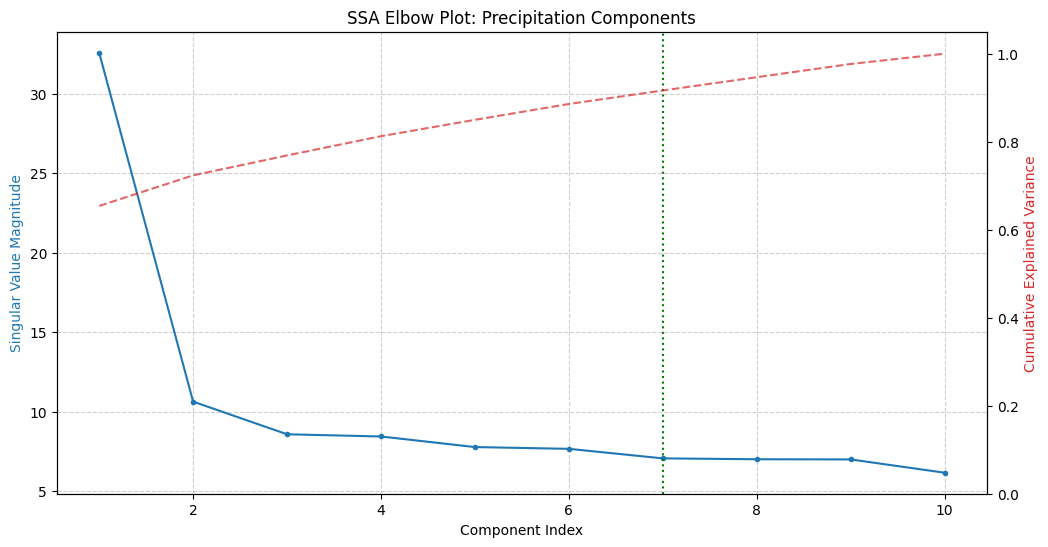

In [480]:
component_energies = np.array([np.sum(c**2) for c in components])
singular_values = np.sqrt(component_energies)

# 2. Sort them (SSA components are usually already sorted)
idx = np.argsort(singular_values)[::-1]
singular_values = singular_values[idx]

# 3. Calculate Variance Explained
total_var = np.sum(singular_values**2)
explained_variance = (singular_values**2) / total_var
cumulative_variance = np.cumsum(explained_variance)

# --- PLOTTING ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Singular Values (The Elbow)
ax1.plot(range(1, L + 1), singular_values, marker='o', markersize=3, color='tab:blue', label='Singular Values')
ax1.set_xlabel('Component Index')
ax1.set_ylabel('Singular Value Magnitude', color='tab:blue')
ax1.set_title('SSA Elbow Plot: Precipitation Components')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Cumulative Variance (To see how much info you keep)
ax2 = ax1.twinx()
ax2.plot(range(1, L + 1), cumulative_variance, color='tab:red', linestyle='--', alpha=0.7, label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance', color='tab:red')
ax2.set_ylim(0, 1.05)

# Add a vertical line at a suggested cutoff (e.g., where 90% variance is reached)
cutoff_90 = np.where(cumulative_variance >= 0.90)[0][0] + 1
ax1.axvline(x=cutoff_90, color='green', linestyle=':', label=f'90% Var ({cutoff_90} comps)')

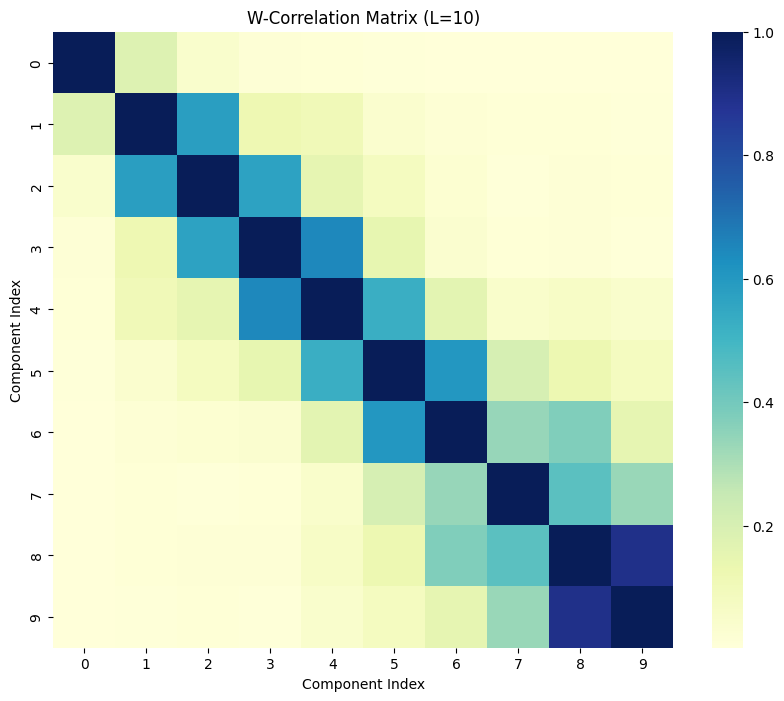

In [481]:
def plot_w_correlation(components):
    L, N = components.shape
    # Define the weights (w_i)
    # This reflects how many times each observation was used in the trajectory matrix
    K = N - L + 1
    w = np.array([min(i + 1, L, N - i) for i in range(N)])
    
    w_corr = np.zeros((L, L))
    
    # Calculate weighted norms once for efficiency
    weighted_norms = [np.sqrt(np.sum(w * (c**2))) for c in components]
    
    for i in range(L):
        for j in range(i, L):
            numerator = np.sum(w * components[i] * components[j])
            denominator = weighted_norms[i] * weighted_norms[j]
            val = abs(numerator / denominator)
            w_corr[i, j] = val
            w_corr[j, i] = val # Matrix is symmetric
            
    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(w_corr, cmap='YlGnBu', annot=False)
    plt.title(f'W-Correlation Matrix (L={L})')
    plt.xlabel('Component Index')
    plt.ylabel('Component Index')
    plt.show()
    
    return w_corr

# Use it on your first 20-30 components (plotting 365 is too dense to read)
w_matrix = plot_w_correlation(components[:120])

C:\Users\crist\AppData\Local\Temp\ipykernel_27016\1079277040.py:37: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


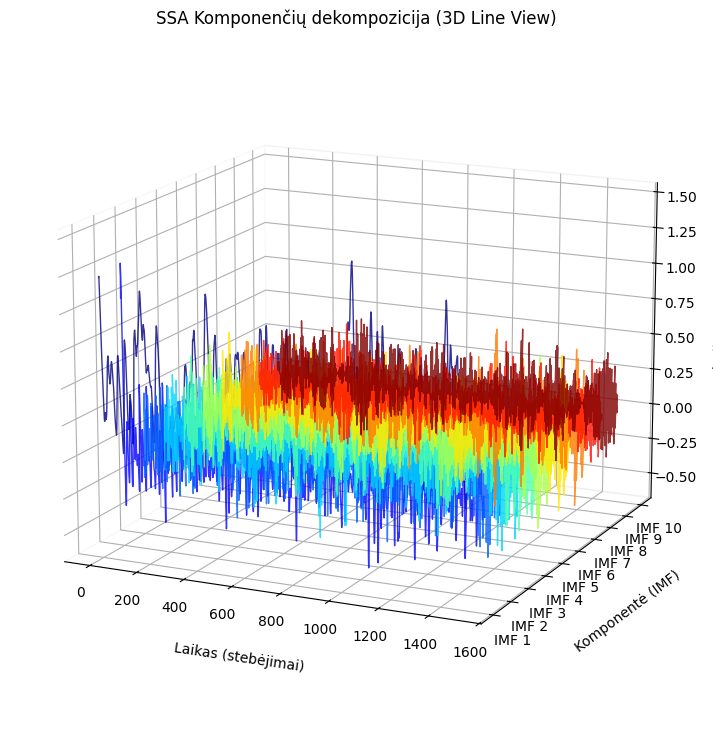

In [482]:
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')
# Nustatome segmentą vizualizacijai (pvz., pirmos 1500 valandų)
n_points = min(1500, len(series))
x = np.arange(n_points)
zs = np.arange(n_comp)

# Spalvų paletė
colors = plt.cm.jet(np.linspace(0, 1, n_comp))

for i in range(n_comp):
    y = components[i][:n_points]
    # Kiekvieną komponentę nubraižome kaip liniją tam tikrame gylio (z) lygmenyje
    # Naudojame plot() funkciją, kur y ašis (gylis) yra konstanta 'i'
    ax.plot(x, [i] * n_points, y, color=colors[i], linewidth=1, alpha=0.8)

# 3. Estetika ir kampas (kad būtų kaip image_4a4242.jpg)
ax.set_xlabel('Laikas (stebėjimai)', labelpad=15)
ax.set_ylabel('Komponentė (IMF)', labelpad=15)
ax.set_zlabel('Krituliai (mm)', labelpad=10)

# Kameros nustatymai: 
# elev (aukštis virš horizonto) - mažesnis skaičius žiūri labiau iš priekio
# azim (pasukimas aplink Z ašį) - nustatykite pagal tai, kiek "šono" norite matyti
ax.view_init(elev=15, azim=-65) 

# Nuimame pilką foną, kad būtų švariau (panašiai kaip pavyzdyje)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# Nustatome y ašies žymas (komponenčių numerius)
ax.set_yticks(zs)
ax.set_yticklabels([f'IMF {i+1}' for i in zs])

plt.title("SSA Komponenčių dekompozicija (3D Line View)")
plt.tight_layout()
plt.show()

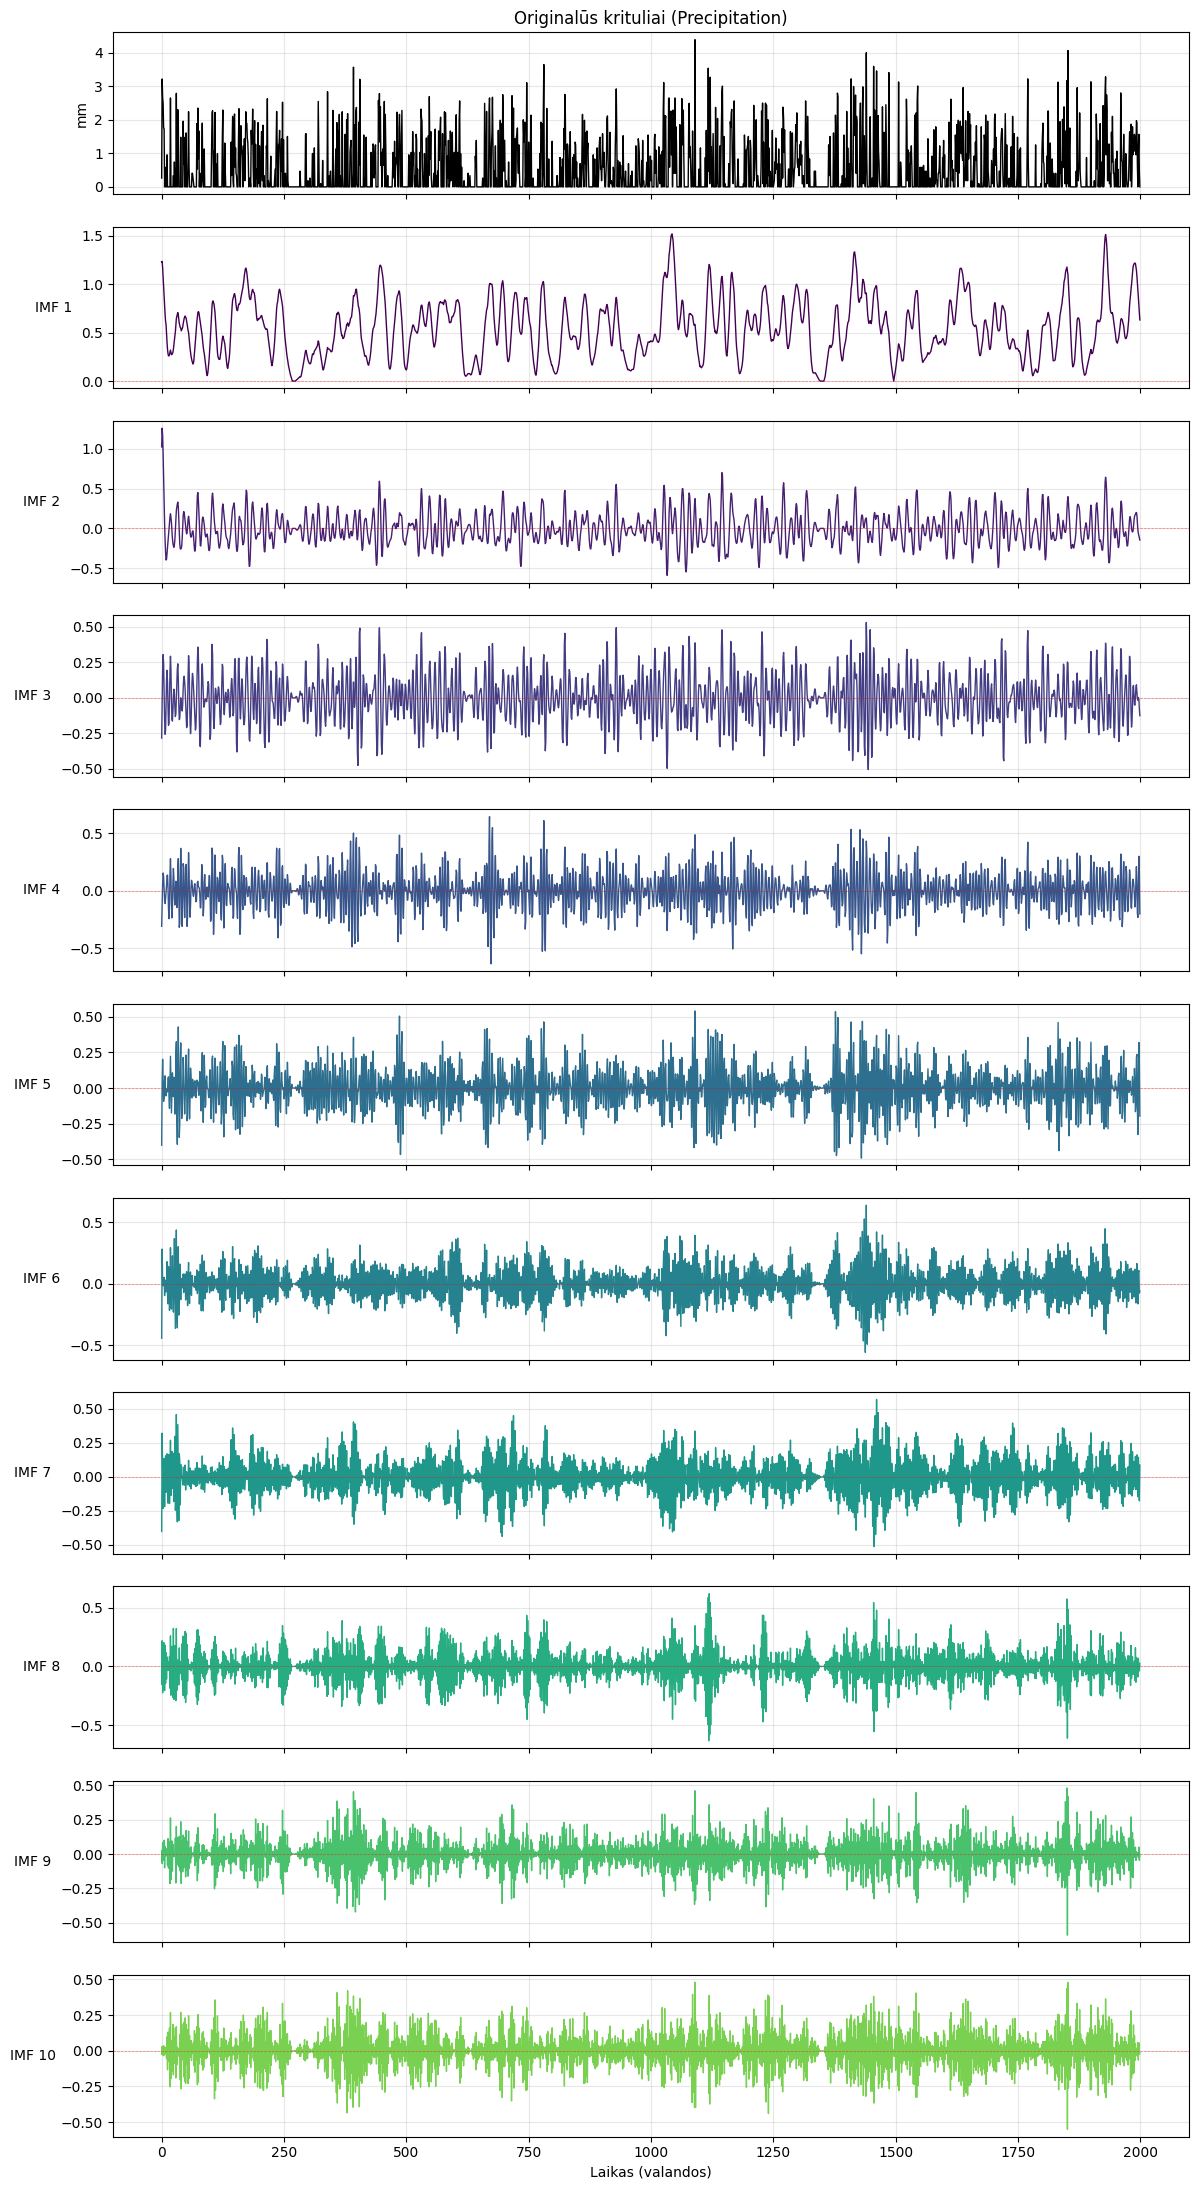

In [483]:
N = 10

fig, axes = plt.subplots(N + 1, 1, figsize=(12, 2 * (N + 1)), sharex=True)

# Nustatome segmentą vizualizacijai (pvz., pirmos 2000 valandų)
n_points = min(2000, len(series))
time_axis = np.arange(n_points)

# Viršutinis grafikas - Originalūs duomenys
axes[0].plot(time_axis, series[:n_points], color='black', linewidth=1)
axes[0].set_title('Originalūs krituliai (Precipitation)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('mm')

# Komponenčių grafikai
colors = plt.cm.viridis(np.linspace(0, 0.8, N))

for i in range(N):
    ax = axes[i + 1]
    ax.plot(time_axis, components[i][:n_points], color=colors[i], linewidth=1)
    ax.set_ylabel(f'IMF {i+1}', rotation=0, labelpad=20, verticalalignment='center')
    ax.grid(True, alpha=0.3)
    
    # Pridedame nulio liniją geresniam matomumui
    ax.axhline(0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

# Ašies nustatymai
axes[-1].set_xlabel('Laikas (valandos)')

# Sutvarkome tarpus, kad grafikai nesuliptų
plt.tight_layout()
plt.subplots_adjust(hspace=0.2) # Galite pareguliuoti tarpus tarp grafikų

plt.show()

In [484]:
how_group = {
    '1': [0],
    '2': [1],
    '3': [2],
    '4': [3],
    '5': [4],
    '6': [5],
    '7': [6],
    '8': [7, 8, 9],
}

# how_group = {
#     '1': [0],
#     '2': [1],
#     '3': [2],
#     '4': [3, 4],
#     '5': [5],
#     '6': [6, 7, 8, 9],
#     '7': [10, 11, 12],
#     '8': np.arange(13, 120, 1)
# }

grouped = []
for key in how_group:
    new_comp = np.zeros_like(components[0])
    for idx in how_group[key]:
        new_comp += components[idx]
    grouped.append(new_comp)

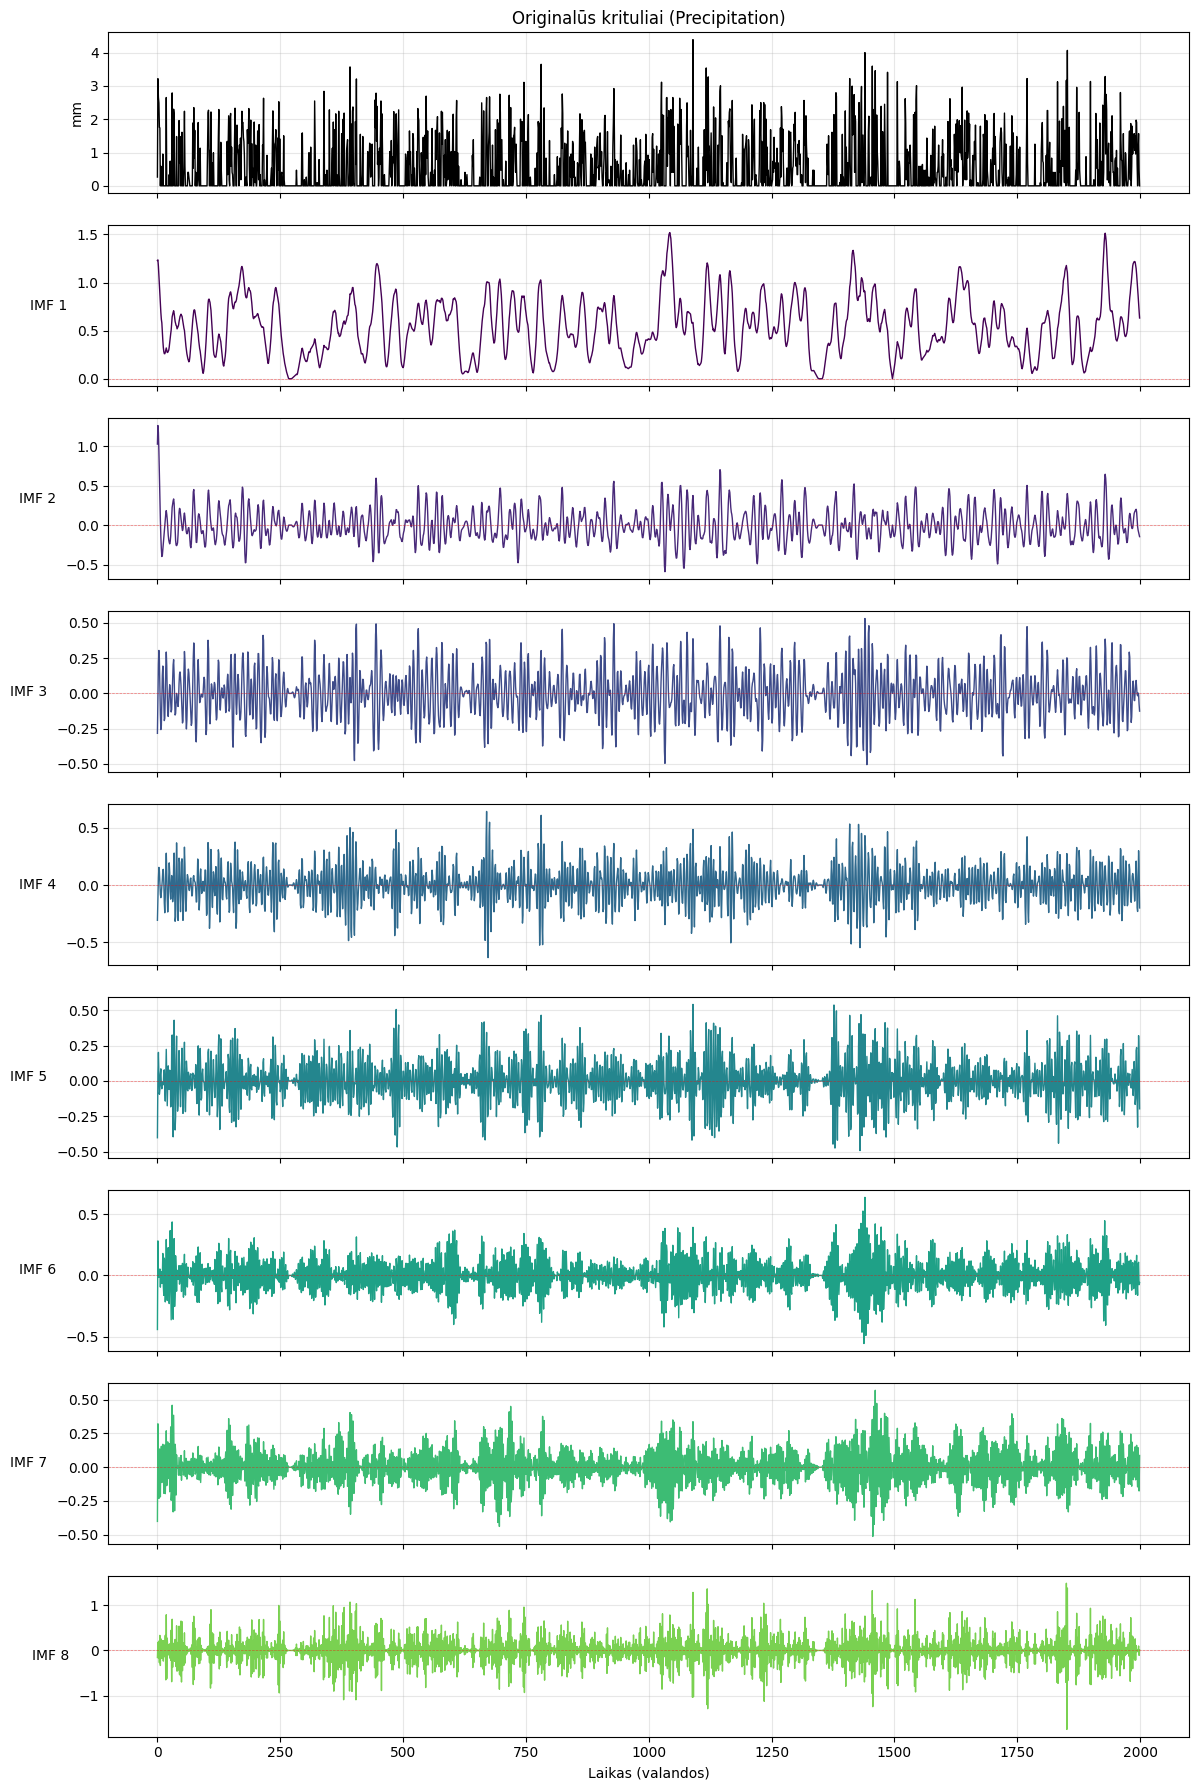

In [485]:
N = 8

fig, axes = plt.subplots(N + 1, 1, figsize=(12, 2 * (N + 1)), sharex=True)

# Nustatome segmentą vizualizacijai (pvz., pirmos 2000 valandų)
n_points = min(2000, len(series))
time_axis = np.arange(n_points)

# Viršutinis grafikas - Originalūs duomenys
axes[0].plot(time_axis, series[:n_points], color='black', linewidth=1)
axes[0].set_title('Originalūs krituliai (Precipitation)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('mm')

# Komponenčių grafikai
colors = plt.cm.viridis(np.linspace(0, 0.8, N))

for i in range(N):
    ax = axes[i + 1]
    ax.plot(time_axis, grouped[i][:n_points], color=colors[i], linewidth=1)
    ax.set_ylabel(f'IMF {i+1}', rotation=0, labelpad=20, verticalalignment='center')
    ax.grid(True, alpha=0.3)
    
    # Pridedame nulio liniją geresniam matomumui
    ax.axhline(0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

# Ašies nustatymai
axes[-1].set_xlabel('Laikas (valandos)')

# Sutvarkome tarpus, kad grafikai nesuliptų
plt.tight_layout()
plt.subplots_adjust(hspace=0.2) # Galite pareguliuoti tarpus tarp grafikų

plt.show()

# SSA Mokymo testavimo aibės


## Skirstymas

In [449]:
split_idx = int(len(X) * 0.9)

X_train, X_test = X[:split_idx], X[split_idx:]

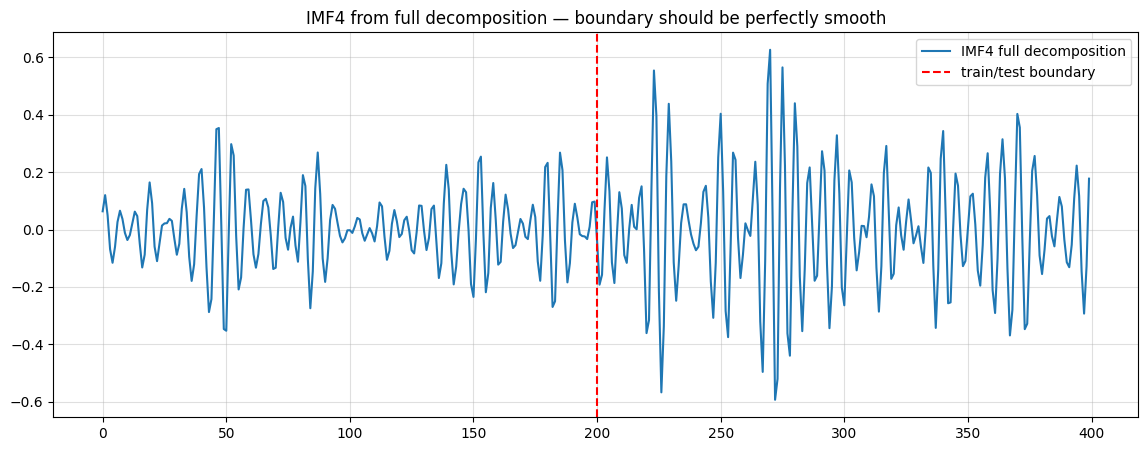

In [450]:
# --- Decompose the FULL series before splitting ---
L = 10
n_components = 10

# Full series (before train/test split)
series_full_log = np.log1p(X['missforest_precipitation'].values)

ssa_full = SingularSpectrumAnalysis(window_size=L, lower_frequency_bound=0.1)
components_full = ssa_full.fit_transform(series_full_log.reshape(1, -1))[0]

# Group components
grouped_full = []
for key in how_group:
    new_comp = np.zeros_like(components_full[0])
    for idx in how_group[key]:
        new_comp += components_full[idx]
    grouped_full.append(new_comp)

# Now split AFTER decomposition — same split_idx you used before
split_idx = int(len(X) * 0.9)

# Verify boundary is smooth for IMF4
plt.figure(figsize=(14, 5))
n = 200
boundary_region = grouped_full[3][split_idx - n : split_idx + n]
plt.plot(boundary_region, linewidth=1.5, label='IMF4 full decomposition')
plt.axvline(x=n, color='red', linestyle='--', label='train/test boundary')
plt.title('IMF4 from full decomposition — boundary should be perfectly smooth')
plt.legend(); plt.grid(True, alpha=0.4); plt.show()

# Assign back into X_train / X_test
for i, key in enumerate(how_group):
    X.loc[X.index, f'IMF{i+1}'] = grouped_full[i]

# Re-split
X_train_new = X.iloc[:split_idx].copy()
X_test_new  = X.iloc[split_idx:].copy()

# Rebuild y_train, y_test
y_train_new = X_train_new[['IMF1','IMF2','IMF3','IMF4','IMF5','IMF6','IMF7','IMF8']]
y_test_new  = X_test_new[['IMF1','IMF2','IMF3','IMF4','IMF5','IMF6','IMF7','IMF8']]

In [451]:
X_train = X_train_new.copy()
X_test  = X_test_new.copy()

X_train['NO2_mean_7'] = X_train['NO2'].rolling(window=7).mean()
X_train['nmvoc_mean_5'] = X_train['nmvoc'].rolling(window=5).mean()
X_train['dust_mean_7'] = X_train['dust'].rolling(window=7).mean()
X_train['pm10_mean_5'] = X_train['pm10'].rolling(window=5).mean()

X_test['NO2_mean_7'] = X_test['NO2'].rolling(window=7).mean()
X_test['nmvoc_mean_5'] = X_test['nmvoc'].rolling(window=5).mean()
X_test['dust_mean_7'] = X_test['dust'].rolling(window=7).mean()
X_test['pm10_mean_5'] = X_test['pm10'].rolling(window=5).mean()

X_train = X_train.dropna()
X_test = X_test.dropna()

In [452]:
y_train = X_train[['IMF1', 'IMF2', 'IMF3', 'IMF4', 'IMF5', 'IMF6', 'IMF7', 'IMF8']]
y_test = X_test[['IMF1', 'IMF2', 'IMF3', 'IMF4', 'IMF5', 'IMF6', 'IMF7', 'IMF8']]

In [453]:
X_train = X_train[:-1].drop(columns=['observationTime'])
y_train = y_train[1:]

In [454]:
X_test = X_test[:-1].drop(columns=['observationTime'])
y_test = y_test[1:]

In [455]:
sklearn.set_config(transform_output="pandas")
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## IMF1

In [456]:
select_features_lasso(X_train, 'IMF1')

Pradinis požymių skaičius: 67
Išlikusių požymių skaičius: 32
Geriausias lambda (alpha): 0.0020
Pašalinti požymiai: ['BrO', 'IMF7', 'dust_mean_7', 'NO2_lag8', 'pans', 'NO2_lag6', 'NO2_lag7', 'IMF8', 'windSpeed_fixed', 'NO2_lag4', 'pm2p5', 'IMF5', 'O3_Error', 'month_sin', 'H2O_column_number_density_lag1', 'windDirection_fixed', 'stratospheric_NO2_column_number_density', 'month', 'day_of_week', 'sia', 'NO2_mean_7', 'IMF3', 'pm10', 'NO2_column_number_density_lag2', 'nh3_lag1', 'NO2_lag3', 'NO2_lag5', 'windGust_fixed', 'BrO_Error', 'nmvoc_lag1', 't2m', 'NO2_lag2', 'NO2_lag1', 'NO2_lag9', 'pm10_lag1']


['absorbing_aerosol_index',
 'NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'NO2',
 'NO2_Error',
 'O3',
 'nmvoc',
 'dust',
 'nh3',
 'tp',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'day_of_year',
 'month_cos',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag3',
 'nh3_lag2',
 'nh3_lag11',
 'pans_lag10',
 'dust_lag1',
 'IMF2',
 'IMF4',
 'IMF6',
 'nmvoc_mean_5',
 'pm10_mean_5',
 'IMF1']

In [457]:
X_train_IMF1 = X_train[['absorbing_aerosol_index',
 'NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'NO2',
 'NO2_Error',
 'O3',
 'nmvoc',
 'dust',
 'nh3',
 'tp',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'day_of_year',
 'month_cos',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag3',
 'nh3_lag2',
 'nh3_lag11',
 'pans_lag10',
 'dust_lag1',
 'IMF2',
 'IMF4',
 'IMF6',
 'nmvoc_mean_5',
 'pm10_mean_5',
 'IMF1']]

X_test_IMF1 = X_test[['absorbing_aerosol_index',
 'NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'NO2',
 'NO2_Error',
 'O3',
 'nmvoc',
 'dust',
 'nh3',
 'tp',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'day_of_year',
 'month_cos',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag3',
 'nh3_lag2',
 'nh3_lag11',
 'pans_lag10',
 'dust_lag1',
 'IMF2',
 'IMF4',
 'IMF6',
 'nmvoc_mean_5',
 'pm10_mean_5',
 'IMF1']]

## IMF2

In [458]:
select_features_lasso(X_train, 'IMF2')

Pradinis požymių skaičius: 67
Išlikusių požymių skaičius: 45
Geriausias lambda (alpha): 0.0022
Pašalinti požymiai: ['dust', 'IMF7', 'NO2_lag8', 'seaLevelPressure', 'NO2_lag6', 'NO2_lag7', 'windSpeed_fixed', 'NO2_lag4', 'pans_lag10', 'IMF4', 'stratospheric_NO2_column_number_density', 'day_of_week', 'NO2_mean_7', 'missforest_precipitation', 'day_of_year', 'NO2_lag3', 'NO2_lag5', 'BrO_Error', 'airTemperature', 'NO2_lag2', 'NO2_lag9', 'pm10_lag1']


['absorbing_aerosol_index',
 'NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'NO2',
 'NO2_Error',
 'O3',
 'O3_Error',
 'pm10',
 'pm2p5',
 'sia',
 'nmvoc',
 'nh3',
 'pans',
 'tp',
 't2m',
 'relativeHumidity',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'month',
 'month_sin',
 'month_cos',
 'H2O_column_number_density_lag1',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nmvoc_lag1',
 'nh3_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'dust_lag1',
 'NO2_lag1',
 'IMF1',
 'IMF3',
 'IMF5',
 'IMF6',
 'IMF8',
 'nmvoc_mean_5',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF2']

In [459]:
X_train_IMF2 = X_train[['absorbing_aerosol_index',
 'NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'NO2',
 'NO2_Error',
 'O3',
 'O3_Error',
 'pm10',
 'pm2p5',
 'sia',
 'nmvoc',
 'nh3',
 'pans',
 'tp',
 't2m',
 'relativeHumidity',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'month',
 'month_sin',
 'month_cos',
 'H2O_column_number_density_lag1',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nmvoc_lag1',
 'nh3_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'dust_lag1',
 'NO2_lag1',
 'IMF1',
 'IMF3',
 'IMF5',
 'IMF6',
 'IMF8',
 'nmvoc_mean_5',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF2']]

X_test_IMF2 = X_test[['absorbing_aerosol_index',
 'NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'NO2',
 'NO2_Error',
 'O3',
 'O3_Error',
 'pm10',
 'pm2p5',
 'sia',
 'nmvoc',
 'nh3',
 'pans',
 'tp',
 't2m',
 'relativeHumidity',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'month',
 'month_sin',
 'month_cos',
 'H2O_column_number_density_lag1',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nmvoc_lag1',
 'nh3_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'dust_lag1',
 'NO2_lag1',
 'IMF1',
 'IMF3',
 'IMF5',
 'IMF6',
 'IMF8',
 'nmvoc_mean_5',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF2']]

## IMF3

In [460]:
select_features_lasso(X_train, 'IMF3')

Pradinis požymių skaičius: 67
Išlikusių požymių skaičius: 61
Geriausias lambda (alpha): 0.0018
Pašalinti požymiai: ['day_of_year', 'NO2_mean_7', 'pm10', 'NO2_lag6', 'NO2_lag2', 'stratospheric_NO2_column_number_density']


['absorbing_aerosol_index',
 'NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'BrO_Error',
 'NO2',
 'NO2_Error',
 'O3',
 'O3_Error',
 'pm2p5',
 'sia',
 'nmvoc',
 'dust',
 'nh3',
 'pans',
 'tp',
 't2m',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'month',
 'day_of_week',
 'month_sin',
 'month_cos',
 'H2O_column_number_density_lag1',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nmvoc_lag1',
 'nh3_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'pm10_lag1',
 'pans_lag10',
 'dust_lag1',
 'NO2_lag1',
 'NO2_lag3',
 'NO2_lag4',
 'NO2_lag5',
 'NO2_lag7',
 'NO2_lag8',
 'NO2_lag9',
 'IMF1',
 'IMF2',
 'IMF4',
 'IMF5',
 'IMF6',
 'IMF7',
 'IMF8',
 'nmvoc_mean_5',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF3']

In [461]:
X_train_IMF3 = X_train[['absorbing_aerosol_index',
 'NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'BrO_Error',
 'NO2',
 'NO2_Error',
 'O3',
 'O3_Error',
 'pm2p5',
 'sia',
 'nmvoc',
 'dust',
 'nh3',
 'pans',
 'tp',
 't2m',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'month',
 'day_of_week',
 'month_sin',
 'month_cos',
 'H2O_column_number_density_lag1',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nmvoc_lag1',
 'nh3_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'pm10_lag1',
 'pans_lag10',
 'dust_lag1',
 'NO2_lag1',
 'NO2_lag3',
 'NO2_lag4',
 'NO2_lag5',
 'NO2_lag7',
 'NO2_lag8',
 'NO2_lag9',
 'IMF1',
 'IMF2',
 'IMF4',
 'IMF5',
 'IMF6',
 'IMF7',
 'IMF8',
 'nmvoc_mean_5',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF3']]

X_test_IMF3 = X_test[['absorbing_aerosol_index',
 'NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'BrO_Error',
 'NO2',
 'NO2_Error',
 'O3',
 'O3_Error',
 'pm2p5',
 'sia',
 'nmvoc',
 'dust',
 'nh3',
 'pans',
 'tp',
 't2m',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'month',
 'day_of_week',
 'month_sin',
 'month_cos',
 'H2O_column_number_density_lag1',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nmvoc_lag1',
 'nh3_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'pm10_lag1',
 'pans_lag10',
 'dust_lag1',
 'NO2_lag1',
 'NO2_lag3',
 'NO2_lag4',
 'NO2_lag5',
 'NO2_lag7',
 'NO2_lag8',
 'NO2_lag9',
 'IMF1',
 'IMF2',
 'IMF4',
 'IMF5',
 'IMF6',
 'IMF7',
 'IMF8',
 'nmvoc_mean_5',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF3']]

## IMF4

In [462]:
select_features_lasso(X_train, 'IMF4')

Pradinis požymių skaičius: 67
Išlikusių požymių skaičius: 52
Geriausias lambda (alpha): 0.0041
Pašalinti požymiai: ['day_of_year', 'pm2p5', 'NO2_lag5', 'IMF7', 'month_sin', 'NO2_mean_7', 'BrO_Error', 'pm10', 'absorbing_aerosol_index', 'feelsLikeTemperature_fixed', 'NO2_lag6', 'NO2_Error', 'nh3_lag1', 'missforest_precipitation', 'month']


['NO2_column_number_density',
 'stratospheric_NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'NO2',
 'O3',
 'O3_Error',
 'sia',
 'nmvoc',
 'dust',
 'nh3',
 'pans',
 'tp',
 't2m',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'xgb_cloudCover',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'day_of_week',
 'month_cos',
 'H2O_column_number_density_lag1',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nmvoc_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'pm10_lag1',
 'pans_lag10',
 'dust_lag1',
 'NO2_lag1',
 'NO2_lag2',
 'NO2_lag3',
 'NO2_lag4',
 'NO2_lag7',
 'NO2_lag8',
 'NO2_lag9',
 'IMF1',
 'IMF2',
 'IMF3',
 'IMF5',
 'IMF6',
 'IMF8',
 'nmvoc_mean_5',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF4']

In [463]:
X_train_IMF4 = X_train[['NO2_column_number_density',
 'stratospheric_NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'NO2',
 'O3',
 'O3_Error',
 'sia',
 'nmvoc',
 'dust',
 'nh3',
 'pans',
 'tp',
 't2m',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'xgb_cloudCover',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'day_of_week',
 'month_cos',
 'H2O_column_number_density_lag1',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nh3_lag2',
 'nh3_lag11',
 'pm10_lag1',
 'pans_lag10',
 'dust_lag1',
 'NO2_lag1',
 'NO2_lag2',
 'NO2_lag3',
 'NO2_lag4',
 'NO2_lag7',
 'NO2_lag8',
 'NO2_lag9',
 'IMF1',
 'IMF2',
 'IMF3',
 'IMF5',
 'IMF6',
 'IMF8',
 'nmvoc_mean_5',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF4']]

X_test_IMF4 = X_test[['NO2_column_number_density',
 'stratospheric_NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'NO2',
 'O3',
 'O3_Error',
 'sia',
 'nmvoc',
 'dust',
 'nh3',
 'pans',
 'tp',
 't2m',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'xgb_cloudCover',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'day_of_week',
 'month_cos',
 'H2O_column_number_density_lag1',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nh3_lag2',
 'nh3_lag11',
 'pm10_lag1',
 'pans_lag10',
 'dust_lag1',
 'NO2_lag1',
 'NO2_lag2',
 'NO2_lag3',
 'NO2_lag4',
 'NO2_lag7',
 'NO2_lag8',
 'NO2_lag9',
 'IMF1',
 'IMF2',
 'IMF3',
 'IMF5',
 'IMF6',
 'IMF8',
 'nmvoc_mean_5',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF4']]

## IMF5

In [464]:
select_features_lasso(X_train, 'IMF5')

Pradinis požymių skaičius: 67
Išlikusių požymių skaičius: 56
Geriausias lambda (alpha): 0.0036
Pašalinti požymiai: ['NO2_lag3', 'sia', 'IMF7', 'BrO_Error', 'NO2_mean_7', 'pm10', 'H2O_column_number_density_lag1', 'feelsLikeTemperature_fixed', 'NO2_lag7', 'nmvoc_mean_5', 'month']


['absorbing_aerosol_index',
 'NO2_column_number_density',
 'stratospheric_NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'NO2',
 'NO2_Error',
 'O3',
 'O3_Error',
 'pm2p5',
 'nmvoc',
 'dust',
 'nh3',
 'pans',
 'tp',
 't2m',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'day_of_year',
 'day_of_week',
 'month_sin',
 'month_cos',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nmvoc_lag1',
 'nh3_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'pm10_lag1',
 'pans_lag10',
 'dust_lag1',
 'NO2_lag1',
 'NO2_lag2',
 'NO2_lag4',
 'NO2_lag5',
 'NO2_lag6',
 'NO2_lag8',
 'NO2_lag9',
 'IMF1',
 'IMF2',
 'IMF3',
 'IMF4',
 'IMF6',
 'IMF8',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF5']

In [465]:
X_train_IMF5 = X_train[['absorbing_aerosol_index',
 'NO2_column_number_density',
 'stratospheric_NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'NO2',
 'NO2_Error',
 'O3',
 'O3_Error',
 'pm2p5',
 'nmvoc',
 'dust',
 'nh3',
 'pans',
 'tp',
 't2m',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'day_of_year',
 'day_of_week',
 'month_sin',
 'month_cos',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nmvoc_lag1',
 'nh3_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'pm10_lag1',
 'pans_lag10',
 'dust_lag1',
 'NO2_lag1',
 'NO2_lag2',
 'NO2_lag4',
 'NO2_lag5',
 'NO2_lag6',
 'NO2_lag8',
 'NO2_lag9',
 'IMF1',
 'IMF2',
 'IMF3',
 'IMF4',
 'IMF6',
 'IMF7',
 'IMF8',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF5']]

X_test_IMF5 = X_test[['absorbing_aerosol_index',
 'NO2_column_number_density',
 'stratospheric_NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'NO2',
 'NO2_Error',
 'O3',
 'O3_Error',
 'pm2p5',
 'nmvoc',
 'dust',
 'nh3',
 'pans',
 'tp',
 't2m',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'day_of_year',
 'day_of_week',
 'month_sin',
 'month_cos',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nmvoc_lag1',
 'nh3_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'pm10_lag1',
 'pans_lag10',
 'dust_lag1',
 'NO2_lag1',
 'NO2_lag2',
 'NO2_lag4',
 'NO2_lag5',
 'NO2_lag6',
 'NO2_lag8',
 'NO2_lag9',
 'IMF1',
 'IMF2',
 'IMF3',
 'IMF4',
 'IMF6',
 'IMF7',
 'IMF8',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF5']]

## IMF6

In [466]:
select_features_lasso(X_train, 'IMF6')

Pradinis požymių skaičius: 67
Išlikusių požymių skaičius: 51
Geriausias lambda (alpha): 0.0026
Pašalinti požymiai: ['pm2p5', 'NO2_lag3', 'day_of_week', 'sia', 'NO2_lag5', 'BrO_Error', 'NO2_mean_7', 'H2O_column_number_density_lag1', 'pans', 'absorbing_aerosol_index', 'feelsLikeTemperature_fixed', 'month', 'NO2_lag1', 'nmvoc_mean_5', 'NO2_Error', 'stratospheric_NO2_column_number_density']


['NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'NO2',
 'O3',
 'O3_Error',
 'pm10',
 'nmvoc',
 'dust',
 'nh3',
 'tp',
 't2m',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'day_of_year',
 'month_sin',
 'month_cos',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nmvoc_lag1',
 'nh3_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'pm10_lag1',
 'pans_lag10',
 'dust_lag1',
 'NO2_lag2',
 'NO2_lag4',
 'NO2_lag6',
 'NO2_lag7',
 'NO2_lag8',
 'NO2_lag9',
 'IMF1',
 'IMF2',
 'IMF3',
 'IMF4',
 'IMF5',
 'IMF7',
 'IMF8',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF6']

In [467]:
X_train_IMF6 = X_train[['NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'NO2',
 'O3',
 'O3_Error',
 'pm10',
 'nmvoc',
 'dust',
 'nh3',
 'tp',
 't2m',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'day_of_year',
 'month_sin',
 'month_cos',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nmvoc_lag1',
 'nh3_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'pm10_lag1',
 'pans_lag10',
 'dust_lag1',
 'NO2_lag2',
 'NO2_lag3',
 'NO2_lag4',
 'NO2_lag6',
 'NO2_lag7',
 'NO2_lag8',
 'NO2_lag9',
 'IMF1',
 'IMF2',
 'IMF3',
 'IMF4',
 'IMF5',
 'IMF7',
 'IMF8',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF6']]

X_test_IMF6 = X_test[['NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'NO2',
 'O3',
 'O3_Error',
 'pm10',
 'nmvoc',
 'dust',
 'nh3',
 'tp',
 't2m',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'day_of_year',
 'month_sin',
 'month_cos',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nmvoc_lag1',
 'nh3_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'pm10_lag1',
 'pans_lag10',
 'dust_lag1',
 'NO2_lag2',
 'NO2_lag3',
 'NO2_lag4',
 'NO2_lag6',
 'NO2_lag7',
 'NO2_lag8',
 'NO2_lag9',
 'IMF1',
 'IMF2',
 'IMF3',
 'IMF4',
 'IMF5',
 'IMF7',
 'IMF8',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF6']]

## IMF7

In [468]:
select_features_lasso(X_train, 'IMF7')

Pradinis požymių skaičius: 67
Išlikusių požymių skaičius: 33
Geriausias lambda (alpha): 0.0068
Pašalinti požymiai: ['dust', 'dust_mean_7', 'pans', 'feelsLikeTemperature_fixed', 'NO2_lag6', 'NO2_lag7', 'IMF8', 'NO2_Error', 'pans_lag10', 'nh3_lag11', 'pm2p5', 'O3_Error', 'IMF4', 'nmvoc', 'nmvoc_mean_5', 'dust_lag1', 'stratospheric_NO2_column_number_density', 'month', 'day_of_week', 'sia', 'NO2_mean_7', 'H2O_column_number_density', 'NO2_lag3', 'NO2', 'windGust_fixed', 'BrO_Error', 'month_cos', 'airTemperature', 'nmvoc_lag1', 't2m', 'NO2_lag2', 'NO2_lag1', 'NO2_lag9', 'NO2_column_number_density_lag1']


['absorbing_aerosol_index',
 'NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'BrO',
 'O3',
 'pm10',
 'nh3',
 'tp',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'windSpeed_fixed',
 'windDirection_fixed',
 'day_of_year',
 'month_sin',
 'H2O_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nh3_lag1',
 'nh3_lag2',
 'pm10_lag1',
 'NO2_lag4',
 'NO2_lag5',
 'NO2_lag8',
 'IMF1',
 'IMF2',
 'IMF3',
 'IMF5',
 'IMF6',
 'pm10_mean_5',
 'IMF7']

In [469]:
X_train_IMF7 = X_train[['absorbing_aerosol_index',
 'NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'BrO',
 'O3',
 'pm10',
 'nh3',
 'tp',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'windSpeed_fixed',
 'windDirection_fixed',
 'day_of_year',
 'H2O_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nh3_lag1',
 'nh3_lag2',
 'pm10_lag1',
 'NO2_lag4',
 'NO2_lag5',
 'NO2_lag8',
 'IMF1',
 'IMF2',
 'IMF3',
 'IMF5',
 'IMF6',
 'pm10_mean_5',
 'IMF7']]

X_test_IMF7 = X_test[['absorbing_aerosol_index',
 'NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'BrO',
 'O3',
 'pm10',
 'nh3',
 'tp',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'windSpeed_fixed',
 'windDirection_fixed',
 'day_of_year',
 'H2O_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nh3_lag1',
 'nh3_lag2',
 'pm10_lag1',
 'NO2_lag4',
 'NO2_lag5',
 'NO2_lag8',
 'IMF1',
 'IMF2',
 'IMF3',
 'IMF5',
 'IMF6',
 'pm10_mean_5',
 'IMF7']]

## IMF8

In [470]:
select_features_lasso(X_train, 'IMF8')

Pradinis požymių skaičius: 67
Išlikusių požymių skaičius: 35
Geriausias lambda (alpha): 0.0042
Pašalinti požymiai: ['dust', 'BrO', 'dust_mean_7', 'NO2_lag8', 'feelsLikeTemperature_fixed', 'NO2_lag7', 'windSpeed_fixed', 'NO2_lag4', 'nh3_lag11', 'pm2p5', 'nmvoc', 'windDirection_fixed', 'dust_lag1', 'stratospheric_NO2_column_number_density', 'day_of_week', 'NO2_mean_7', 'IMF3', 'H2O_column_number_density', 'missforest_precipitation', 'day_of_year', 'NO2', 'NO2_lag5', 'NO2_slant_column_number_density', 'BrO_Error', 'month_cos', 'airTemperature', 'nmvoc_lag1', 't2m', 'NO2_lag1', 'NO2_lag9', 'NO2_column_number_density_lag1', 'pm10_mean_5']


['absorbing_aerosol_index',
 'NO2_column_number_density',
 'tropopause_pressure',
 'NO2_Error',
 'O3',
 'O3_Error',
 'pm10',
 'sia',
 'nh3',
 'pans',
 'tp',
 'seaLevelPressure',
 'relativeHumidity',
 'xgb_cloudCover',
 'windGust_fixed',
 'month',
 'month_sin',
 'H2O_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nh3_lag1',
 'nh3_lag2',
 'pm10_lag1',
 'pans_lag10',
 'NO2_lag2',
 'NO2_lag3',
 'NO2_lag6',
 'IMF1',
 'IMF2',
 'IMF4',
 'IMF5',
 'IMF6',
 'IMF7',
 'nmvoc_mean_5',
 'IMF8']

In [471]:
X_train_IMF8 = X_train[['absorbing_aerosol_index',
 'NO2_column_number_density',
 'tropopause_pressure',
 'NO2_Error',
 'O3',
 'O3_Error',
 'pm10',
 'sia',
 'nmvoc',
 'nh3',
 'tp',
 'seaLevelPressure',
 'relativeHumidity',
 'xgb_cloudCover',
 'windGust_fixed',
 'month',
 'month_sin',
 'H2O_column_number_density_lag1',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nh3_lag1',
 'pm10_lag1',
 'NO2_lag2',
 'NO2_lag6',
 'IMF1',
 'IMF2',
 'IMF4',
 'IMF5',
 'IMF6',
 'IMF7',
 'nmvoc_mean_5',
 'IMF8']]

X_test_IMF8 = X_test[['absorbing_aerosol_index',
 'NO2_column_number_density',
 'tropopause_pressure',
 'NO2_Error',
 'O3',
 'O3_Error',
 'pm10',
 'sia',
 'nmvoc',
 'nh3',
 'tp',
 'seaLevelPressure',
 'relativeHumidity',
 'xgb_cloudCover',
 'windGust_fixed',
 'month',
 'month_sin',
 'H2O_column_number_density_lag1',
 'NO2_column_number_density_lag1',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nh3_lag1',
 'pm10_lag1',
 'NO2_lag2',
 'NO2_lag6',
 'IMF1',
 'IMF2',
 'IMF4',
 'IMF5',
 'IMF6',
 'IMF7',
 'nmvoc_mean_5',
 'IMF8']]

# LSTM

In [472]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch, time, features)
        out, _ = self.lstm(x)
        last_step = out[:, -1, :]
        return self.fc(last_step)

In [473]:
class SequenceScaler:
    """Standartizuoja X ir suformuoja sliding window sekas."""
    def __init__(self, window_size):
        self.window_size = window_size
        self.scaler = StandardScaler()

    def fit(self, X):
        self.scaler.fit(X)
        return self

    def transform(self, X):
        X_scaled = self.scaler.transform(X)
        X_seq = []
        for i in range(len(X_scaled) - self.window_size):
            X_seq.append(X_scaled[i:i + self.window_size])
        return np.array(X_seq)

In [474]:
class TweedieLoss(nn.Module):
    """
    Tweedie loss su log-link.
    Reikalauja: target >= 0  (krituliai visada >= 0 ✓)

    LSTM output pred — neribojamas (log erdvė)
    μ = exp(pred) > 0  (nereikia aktyvacijos)

    Gradientas dL/d(pred) = -y·μ^(1-p) + μ^(2-p)
    Kai y=15: gradientas ~20x didesnis nei kai y=0.5
    → modelis stipriai baudžiamas už šuolių praleidimą
    """
    def __init__(self, p=1.5):
        super().__init__()
        assert 1 < p < 2
        self.p = p

    def forward(self, pred, target):
        pred   = pred.squeeze(-1)
        target = target.squeeze(-1)
        mu = torch.exp(pred)
        p  = self.p
        return (-target * mu.pow(1 - p) / (1 - p) + mu.pow(2 - p) / (2 - p)).mean()

In [475]:
class LSTMNet(NeuralNetRegressor):
    def __init__(self, base_module, window_size=10, **net_params):
        self.base_module = base_module
        self.window_size = window_size
        if 'module' not in net_params:
            net_params['module'] = base_module

        super().__init__(**net_params)

    # def __sklearn_tags__(self):
    #     return {"estimator_type": "regressor"}

    # def fit(self, X, y, **fit_params):
    #     ws = self.window_size

    #     # 1. Features: sliding window sekos
    #     self.seq = SequenceScaler(window_size=ws)
    #     self.seq.fit(X)
    #     X_seq = self.seq.transform(X)        # (N-ws, ws, F)

    #     # 2. Target standartizacija
    #     # self.y_scaler = StandardScaler()
    #     # y_scaled = self.y_scaler.fit_transform(y.reshape(-1, 1)).ravel()  # (N,)
    #     y_scaled = y.reshape(-1, 1)

    #     # 3. Alignment: X_seq[j] -> window [j, j+ws), target = y[j+ws]
    #     y_trunc = y_scaled[ws:]              # (N-ws,)

    #     # 4. Vienas LSTM visam targetui
    #     self.model = NeuralNetRegressor(
    #         module=self.base_module,
    #         module__input_dim=X_seq.shape[2],
    #         train_split=ValidSplit(0.2),
    #         callbacks=[
    #             Checkpoint(monitor='valid_loss_best', load_best=True),
    #             EarlyStopping(patience=20)
    #         ],
    #         **self.net_params
    #     )
    #     self.model.fit(X_seq.astype(np.float32), y_trunc.astype(np.float32))
    #     return self
    
    def fit(self, X, y, **fit_params):
        ws = self.window_size

        # 1. Paruošiame sekas (naudojame self.window_size, kurį GridSearch keis)
        self.seq = SequenceScaler(window_size=ws)
        self.seq.fit(X)
        X_seq = self.seq.transform(X)        # (N-ws, ws, F)

        # 2. Target paruošimas (suvienodiname ilgį su X_seq)
        y_trunc = y[ws:].reshape(-1, 1)      # (N-ws, 1)

        # 3. Konvertuojame į float32 (būtina PyTorch)
        X_seq = X_seq.astype(np.float32)
        y_trunc = y_trunc.astype(np.float32)

        # 4. SVARBU: Atnaujiname modelio parametrus prieš treniravimą
        # Kadangi paveldime iš NeuralNetRegressor, parametrai nustatomi per self.set_params
        self.set_params(module__input_dim=X_seq.shape[2])
        
        # Pridedame EarlyStopping ir kitus callbacks, jei jų dar nėra
        if 'callbacks' not in self.get_params():
             self.set_params(callbacks=[
                Checkpoint(monitor='valid_loss_best', load_best=True),
                EarlyStopping(patience=20)
            ])

        # 5. Kviečiame bazinį skorch fit su apdorotais duomenimis
        # Tai leis GridSearchCV matyti progresą ir skaičiuoti score
        return super().fit(X_seq, y_trunc, **fit_params)
    
    def predict(self, X):
        # 1. Paruošiame sekas iš X_test naudojant fit metu sukurtą seq objektą
        X_seq = self.seq.transform(X)        # (M-ws, ws, F)
        
        # 2. Kviečiame bazinį skorch predict metodą
        # Nebenaudojame self.model.predict, o naudojame super().predict
        y_scaled_pred = super().predict(X_seq.astype(np.float32))
        
        # 3. Grąžiname rezultatą (be de-standartizacijos, jei jos nenaudoji)
        return y_scaled_pred.reshape(-1, 1)

# SSA-LSTM
## IMF1

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 14}

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 5}

In [525]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=5,

    module__hidden_dim=128,
    module__num_layers=1,
    module__dropout=0.3,
    optimizer__weight_decay = 0,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=750,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [526]:
pipeline.fit(X_train_IMF1.values, y_train['IMF1'].values)
pred = pipeline.predict(X_test_IMF1.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0620        0.0176     +  0.3185
      2        0.0141        0.0089     +  0.2476
      3        0.0090        0.0093        0.2342
      4        0.0069        0.0067     +  0.2202
      5        0.0051        0.0059     +  0.2233
      6        0.0040        0.0051     +  0.2235
      7        0.0031        0.0045     +  0.2137
      8        0.0035        0.0042     +  0.2288
      9        0.0033        0.0042     +  0.2244
     10        0.0049        0.0047        0.2170
     11        0.0023        0.0028     +  0.2344
     12        0.0016        0.0024     +  0.2182
     13        0.0011        0.0020     +  0.2162
     14        0.0017        0.0021        0.2149
     15        0.0012        0.0019     +  0.2123
     16        0.0016        0.0030        0.2167
     17        0.0030        0.0025        0.2139
     18        0.0013        0.0025        0.2171


In [257]:
param_grid = {
    'window_size': [5, 7, 14],
    'module__hidden_dim': [64, 128],
    'module__num_layers': [1, 2, 3],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2, 0.3],
    'batch_size': [32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF1.values, y_train['IMF1'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF1.values)

Fitting 2 folds for each of 54 candidates, totalling 108 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.1041        0.0592     +  0.1419
      2        0.0261        0.0159     +  0.1176
      3        0.0148        0.0153     +  0.1107
      4        0.0083        0.0155        0.0936
      5        0.0067        0.0120     +  0.0722
      6        0.0055        0.0112     +  0.0816
      7        0.0046        0.0116        0.0890
      8        0.0040        0.0114        0.1011
      9        0.0035        0.0106     +  0.0888
     10        0.0031        0.0094     +  0.0808
     11        0.0027        0.0088     +  0.0729
     12        0.0026        0.0088        0.0771
     13        0.0023        0.0094        0.0856
     14        0.0022        0.0145        0.0977
     15        0.0039        0.0215        0.0860
     16        0.0041        0.0114        0.0898
     17        0.0054        0.0105   

In [530]:
y_true = y_test['IMF1'].values.astype(float)
# y_true = np.expm1(y_true)

y_true =  y_true[5:]
y_pred = np.array(pred).reshape(-1)
# y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
min_len = min(len(y_true), len(y_pred))
y_true = y_true[:min_len]
y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF1 = y_true[9:]
y_pred_IMF1 = y_pred[9:]

RMSE:     0.0462
MAE:      0.0350
R2:       0.9811
Spearman: 0.9920


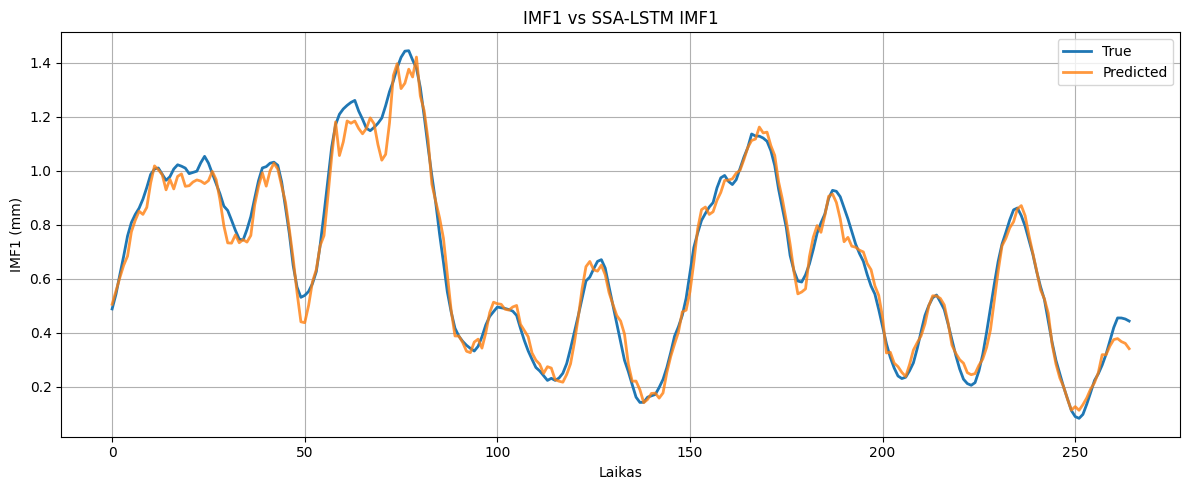

In [531]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True",      linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF1 vs SSA-LSTM IMF1")
plt.xlabel("Laikas")
plt.ylabel("IMF1 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF2

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 5}

In [493]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=5,

    module__hidden_dim=128,
    module__num_layers=1,
    module__dropout=0.2,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=20, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1.0),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [494]:
pipeline.fit(X_train_IMF2.values, y_train['IMF2'].values)
pred = pipeline.predict(X_test_IMF2.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0154        0.0065     +  0.3612
      2        0.0062        0.0049     +  0.2611
      3        0.0034        0.0032     +  0.2350
      4        0.0023        0.0020     +  0.2346
      5        0.0018        0.0023        0.2383
      6        0.0015        0.0019     +  0.2355
      7        0.0011        0.0017     +  0.2225
      8        0.0010        0.0017     +  0.2491
      9        0.0009        0.0018        0.2324
     10        0.0009        0.0016     +  0.2325
     11        0.0008        0.0018        0.2312
     12        0.0010        0.0016     +  0.2309
     13        0.0011        0.0020        0.2250
     14        0.0013        0.0026        0.2267
     15        0.0013        0.0021        0.2298
     16        0.0010        0.0015     +  0.2213
     17        0.0008        0.0017        0.2259
     18        0.0006        0.0017        0.2309


In [265]:
param_grid = {
    'window_size': [5, 7, 14],
    'module__hidden_dim': [64, 128],
    'module__num_layers': [1, 2, 3],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2, 0.3],
    'batch_size': [32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF2.values, y_train['IMF2'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF2.values)

Fitting 2 folds for each of 108 candidates, totalling 216 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0174        0.0183     +  0.0934
      2        0.0111        0.0150     +  0.1106
      3        0.0080        0.0133     +  0.0774
      4        0.0057        0.0118     +  0.0723
      5        0.0040        0.0108     +  0.0732
      6        0.0028        0.0099     +  0.0878
      7        0.0021        0.0115        0.0886
      8        0.0026        0.0100        0.0731
      9        0.0024        0.0136        0.0700
     10        0.0047        0.0113        0.0752
     11        0.0038        0.0094     +  0.0739
     12        0.0023        0.0071     +  0.0671
     13        0.0016        0.0072        0.0680
     14        0.0011        0.0066     +  0.0743
     15        0.0007        0.0063     +  0.0729
     16        0.0006        0.0066        0.0706
     17        0.0006        0.0064  

In [495]:
y_true = y_test['IMF2'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[5:]
y_pred = np.array(pred).reshape(-1)
# y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
# min_len = min(len(y_true), len(y_pred))
# y_true = y_true[:min_len]
# y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF2 = y_true[9:]
y_pred_IMF2 = y_pred[9:]

RMSE:     0.0550
MAE:      0.0424
R2:       0.9334
Spearman: 0.9631


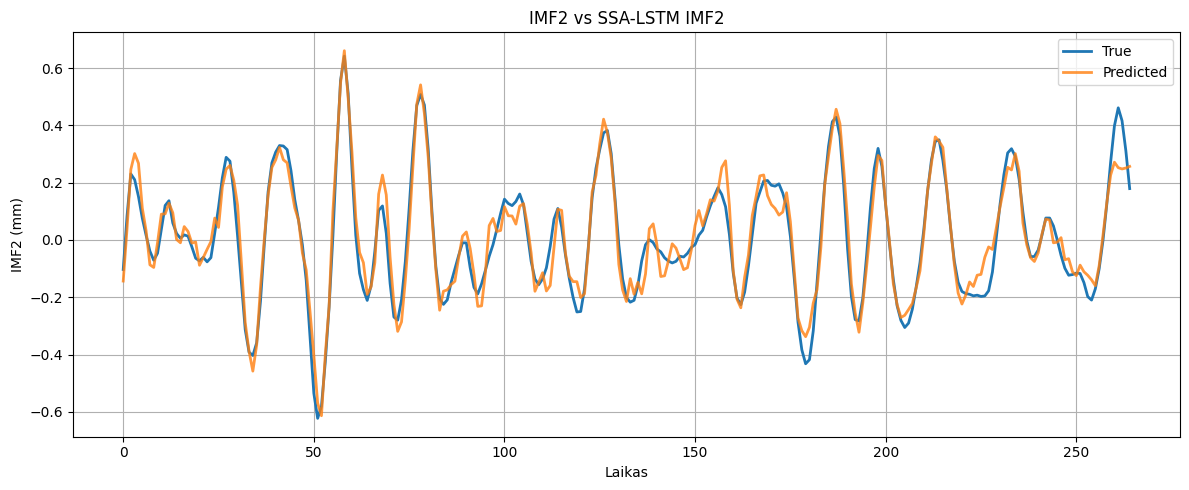

In [496]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True",      linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF2 vs SSA-LSTM IMF2")
plt.xlabel("Laikas")
plt.ylabel("IMF2 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF3

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 5}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.4, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 3}

In [497]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=3,

    module__hidden_dim=256,
    module__num_layers=1,
    module__dropout=0.4,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    # criterion=nn.HuberLoss(delta=1.0),
    criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [498]:
pipeline.fit(X_train_IMF3.values, y_train['IMF3'].values)
pred = pipeline.predict(X_test_IMF3.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0271        0.0115     +  0.4837
      2        0.0071        0.0066     +  0.3299
      3        0.0034        0.0027     +  0.2743
      4        0.0016        0.0020     +  0.2338
      5        0.0010        0.0017     +  0.2117
      6        0.0009        0.0016     +  0.1954
      7        0.0009        0.0016     +  0.1930
      8        0.0007        0.0013     +  0.1878
      9        0.0011        0.0015        0.2045
     10        0.0016        0.0017        0.2052
     11        0.0013        0.0021        0.1945
     12        0.0012        0.0016        0.2068
     13        0.0007        0.0011     +  0.2056
     14        0.0005        0.0010     +  0.2108
     15        0.0004        0.0010     +  0.2308
     16        0.0003        0.0010     +  0.2010
     17        0.0003        0.0010        0.2086
     18        0.0003        0.0011        0.2009


In [342]:
param_grid = {
    'window_size': [3, 5],
    'module__hidden_dim': [64, 128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001, 0.1],          
    'module__dropout': [0.3, 0.4],
    'batch_size': [16, 32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF3.values, y_train['IMF3'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF3.values)

Fitting 2 folds for each of 96 candidates, totalling 192 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0268        0.0260     +  0.1514
      2        0.0178        0.0285        0.1893
      3        0.0227        0.0248     +  0.1631
      4        0.0183        0.0140     +  0.1564
      5        0.0105        0.0117     +  0.1483
      6        0.0059        0.0084     +  0.1299
      7        0.0033        0.0080     +  0.1713
      8        0.0022        0.0088        0.1219
      9        0.0021        0.0076     +  0.1260
     10        0.0017        0.0074     +  0.1292
     11        0.0018        0.0105        0.1258
     12        0.0018        0.0103        0.1381
     13        0.0036        0.0106        0.1291
     14        0.0050        0.0081        0.1225
     15        0.0050        0.0091        0.1280
     16        0.0033        0.0067     +  0.1295
     17        0.0018        0.0057   

In [499]:
y_true = y_test['IMF3'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[3:]
y_pred = np.array(pred).reshape(-1)
# y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
# min_len = min(len(y_true), len(y_pred))
# y_true = y_true[:min_len]
# y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF3 = y_true[11:]
y_pred_IMF3 = y_pred[11:]

RMSE:     0.0411
MAE:      0.0272
R2:       0.9476
Spearman: 0.9814


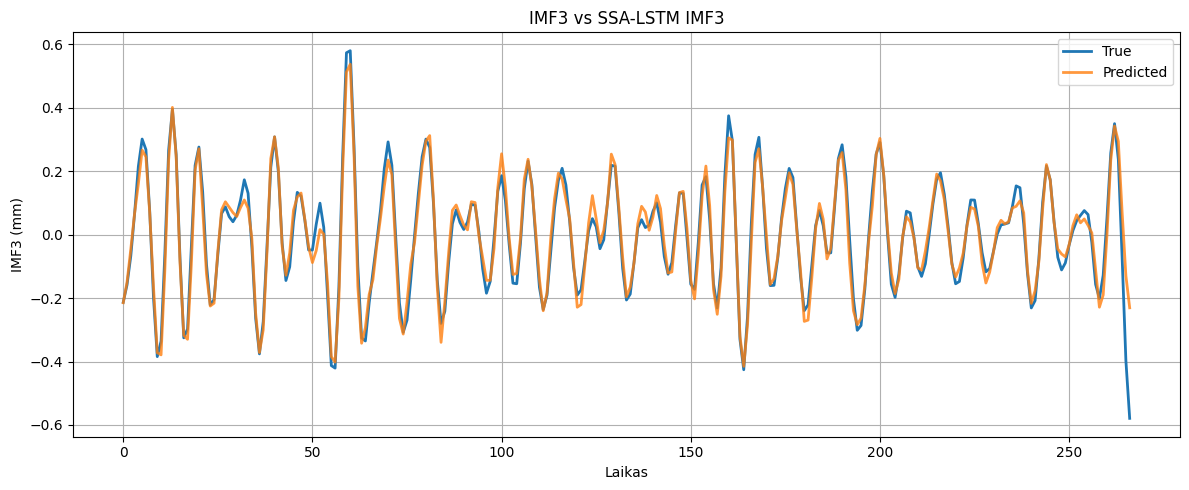

In [500]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True",      linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF3 vs SSA-LSTM IMF3")
plt.xlabel("Laikas")
plt.ylabel("IMF3 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF4

In [501]:
class LSTMFCRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Vietoj vieno fc sluoksnio, naudojame Sequential bloką su LeakyReLU.
        # Tai padeda modeliui "ištraukti" triukšmo pikus, kurių paprastas fc nepagautų.
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1), 
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        # Naudojame paskutinį laiko žingsnį
        return self.fc(out[:, -1, :])

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 14}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 3}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 3}

In [502]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=3,

    module__hidden_dim=256,
    module__num_layers=1,
    module__dropout=0.2,
    optimizer__weight_decay = 0,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=12, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=nn.HuberLoss(delta=0.6),
    criterion=nn.L1Loss(),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [503]:
pipeline.fit(X_train_IMF4.values, y_train['IMF4'].values)
pred = pipeline.predict(X_test_IMF4.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.1205        0.0890     +  0.5002
      2        0.0645        0.0694     +  0.3092
      3        0.0510        0.0440     +  0.2231
      4        0.0391        0.0509        0.2184
      5        0.0543        0.0428     +  0.2256
      6        0.0459        0.0487        0.2280
      7        0.0334        0.0359     +  0.2172
      8        0.0370        0.0531        0.2383
      9        0.0390        0.0296     +  0.2101
     10        0.0263        0.0330        0.2071
     11        0.0246        0.0220     +  0.2451
     12        0.0252        0.0273        0.2194
     13        0.0324        0.0383        0.2186
     14        0.0331        0.0257        0.2120
     15        0.0266        0.0348        0.2236
     16        0.0244        0.0239        0.2180
     17        0.0201        0.0341        0.2647
     18        0.0269        0.0283        0.2393


In [348]:
param_grid = {
    'window_size': [3, 5],
    'module__hidden_dim': [64, 128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2],
    'batch_size': [16, 32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF4.values, y_train['IMF4'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF4.values)

Fitting 2 folds for each of 48 candidates, totalling 96 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.1157        0.1160     +  0.1566
      2        0.0871        0.0901     +  0.1443
      3        0.0837        0.1173        0.1481
      4        0.0718        0.0736     +  0.1418
      5        0.0705        0.0821        0.1551
      6        0.0695        0.0706     +  0.1571
      7        0.0622        0.0740        0.1595
      8        0.0503        0.0651     +  0.1375
      9        0.0393        0.0554     +  0.1601
     10        0.0342        0.0464     +  0.1660
     11        0.0345        0.0576        0.1468
     12        0.0342        0.0562        0.1351
     13        0.0389        0.0715        0.1474
     14        0.0425        0.0550        0.1319
     15        0.0397        0.0689        0.1645
     16        0.0430        0.0864        0.1506
     17        0.0478        0.0683    

In [504]:
y_true = y_test['IMF4'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[3:]
y_pred = np.array(pred).reshape(-1)[:]
# y_pred = np.expm1(y_pred)


rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF4 = y_true[11:]
y_pred_IMF4 = y_pred[11:]

RMSE:     0.0330
MAE:      0.0259
R2:       0.9709
Spearman: 0.9855


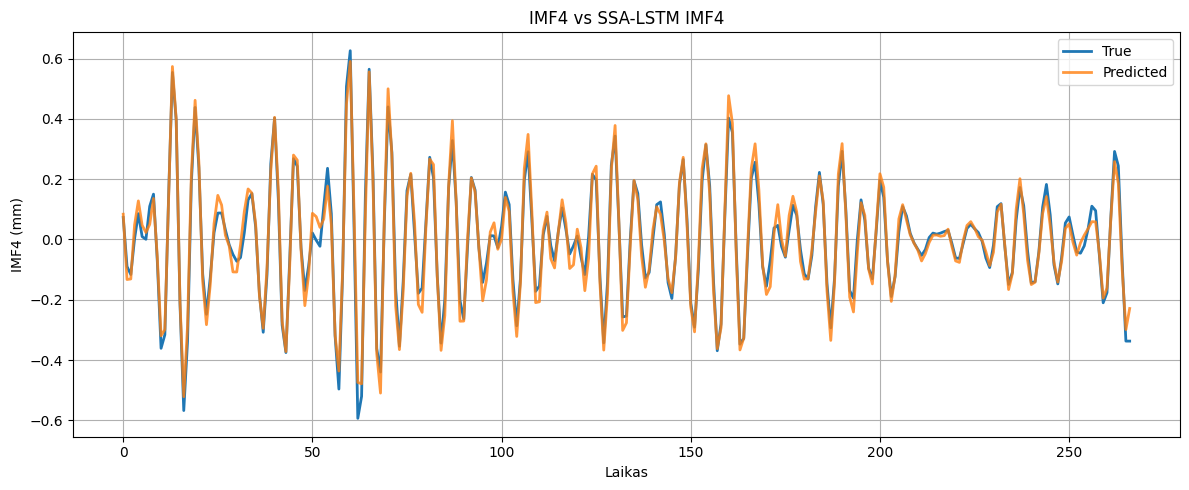

In [505]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True",      linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF4 vs SSA-LSTM IMF4")
plt.xlabel("Laikas")
plt.ylabel("IMF4 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF5

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

{'batch_size': 16, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 64, 'module__num_layers': 2, 'window_size': 5}

In [506]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=5,

    module__hidden_dim=64,
    module__num_layers=2,
    module__dropout=0.2,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=16,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=0.6),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [507]:
pipeline.fit(X_train_IMF5.values, y_train['IMF5'].values)
pred = pipeline.predict(X_test_IMF5.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0082        0.0043     +  0.5364
      2        0.0024        0.0018     +  0.4678
      3        0.0022        0.0018        0.4399
      4        0.0011        0.0011     +  0.4133
      5        0.0009        0.0010     +  0.4151
      6        0.0007        0.0009     +  0.4259
      7        0.0006        0.0009     +  0.4159
      8        0.0005        0.0009        0.4814
      9        0.0005        0.0008     +  0.4527
     10        0.0004        0.0008        0.5112
     11        0.0004        0.0007     +  0.4570
     12        0.0003        0.0006     +  0.4825
     13        0.0004        0.0008        0.4776
     14        0.0004        0.0008        0.4541
     15        0.0004        0.0010        0.4701
     16        0.0005        0.0014        0.4457
     17        0.0005        0.0013        0.4316
     18        0.0004        0.0006     +  0.4322


In [287]:
param_grid = {
    'window_size': [2, 3, 5],
    'module__hidden_dim': [64, 128],
    'module__num_layers': [1, 2, 3],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2, 0.3],
    'batch_size': [16, 32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF5.values, y_train['IMF5'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF5.values)

Fitting 2 folds for each of 108 candidates, totalling 216 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0098        0.0126     +  0.1664
      2        0.0091        0.0123     +  0.1944
      3        0.0087        0.0119     +  0.1602
      4        0.0086        0.0119     +  0.1402
      5        0.0085        0.0118     +  0.1242
      6        0.0083        0.0117     +  0.1243
      7        0.0082        0.0116     +  0.1200
      8        0.0081        0.0115     +  0.1232
      9        0.0080        0.0115     +  0.1235
     10        0.0079        0.0115     +  0.1235
     11        0.0078        0.0115     +  0.1301
     12        0.0078        0.0115        0.1278
     13        0.0078        0.0115        0.1265
     14        0.0077        0.0115     +  0.1199
     15        0.0076        0.0114     +  0.1371
     16        0.0075        0.0116        0.1315
     17        0.0075        0.0117  

In [508]:
y_true = y_test['IMF5'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[5:]
y_pred = np.array(pred).reshape(-1)[:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF5 = y_true[9:]
y_pred_IMF5 = y_pred[9:]

RMSE:     0.0393
MAE:      0.0299
R2:       0.9463
Spearman: 0.9725


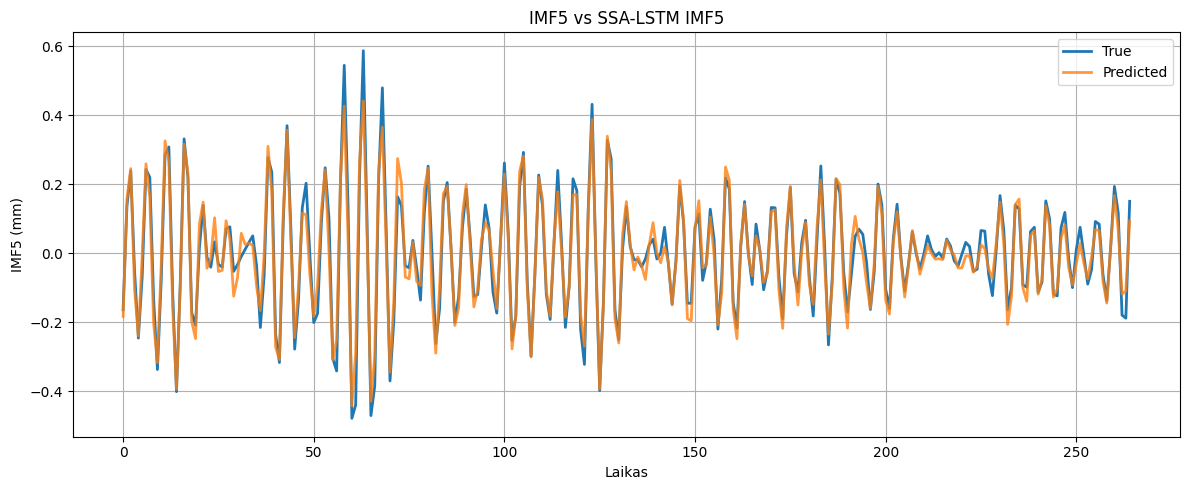

In [509]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True",      linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF5 vs SSA-LSTM IMF5")
plt.xlabel("Laikas")
plt.ylabel("IMF5 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF6

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

{'batch_size': 16, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 7}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 7}

In [510]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=7,

    module__hidden_dim=256,
    module__num_layers=2,
    module__dropout=0.2,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=10, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=0.5),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [511]:
pipeline.fit(X_train_IMF6.values, y_train['IMF6'].values)
pred = pipeline.predict(X_test_IMF6.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0086        0.0055     +  0.5569
      2        0.0040        0.0011     +  0.3256
      3        0.0012        0.0008     +  0.3651
      4        0.0007        0.0006     +  0.3031
      5        0.0006        0.0005     +  0.3007
      6        0.0005        0.0006        0.3490
      7        0.0006        0.0006        0.3344
      8        0.0006        0.0007        0.3292
      9        0.0005        0.0005     +  0.3313
     10        0.0005        0.0008        0.3192
     11        0.0006        0.0006        0.3017
     12        0.0005        0.0007        0.3031
     13        0.0004        0.0005     +  0.3409
     14        0.0004        0.0006        0.3233
     15        0.0004        0.0006        0.3161
     16        0.0004        0.0005        0.3055
     17        0.0003        0.0005        0.3155
     18        0.0003        0.0007        0.3104


In [358]:
param_grid = {
    'window_size': [5, 7],
    'module__hidden_dim': [128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2],
    'batch_size': [16, 32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF6.values, y_train['IMF6'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF6.values)

Fitting 2 folds for each of 32 candidates, totalling 64 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0059        0.0123     +  0.2502
      2        0.0121        0.0113     +  0.2480
      3        0.0045        0.0031     +  0.1873
      4        0.0023        0.0022     +  0.1742
      5        0.0016        0.0018     +  0.1487
      6        0.0009        0.0015     +  0.1461
      7        0.0007        0.0013     +  0.1444
      8        0.0006        0.0012     +  0.1406
      9        0.0005        0.0013        0.1378
     10        0.0004        0.0013        0.1377
     11        0.0004        0.0012     +  0.1375
     12        0.0003        0.0011     +  0.1412
     13        0.0003        0.0017        0.1433
     14        0.0005        0.0027        0.1594
     15        0.0006        0.0013        0.1500
     16        0.0006        0.0027        0.1554
     17        0.0011        0.0021    

In [512]:
y_true = y_test['IMF6'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[7:]
y_pred = np.array(pred).reshape(-1)[:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF6 = y_true[7:]
y_pred_IMF6 = y_pred[7:]

RMSE:     0.0360
MAE:      0.0289
R2:       0.9336
Spearman: 0.9686


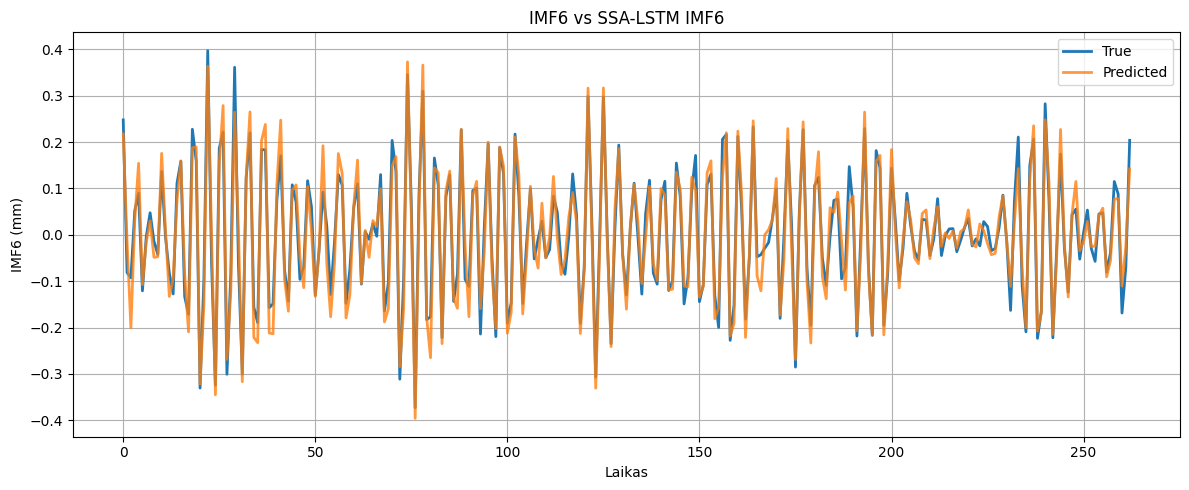

In [513]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True",      linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF6 vs SSA-LSTM IMF6")
plt.xlabel("Laikas")
plt.ylabel("IMF6 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF7

{'batch_size': 32, 'lr': 0.01, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 14}

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 5}

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 5}

In [514]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=5,

    module__hidden_dim=256,
    module__num_layers=1,
    module__dropout=0.1,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.01,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=0.5),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [515]:
pipeline.fit(X_train_IMF7.values, y_train['IMF7'].values)
pred = pipeline.predict(X_test_IMF7.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0159        0.0044     +  0.4169
      2        0.0063        0.0072        0.2266
      3        0.0047        0.0043     +  0.2230
      4        0.0026        0.0034     +  0.2187
      5        0.0019        0.0014     +  0.2283
      6        0.0013        0.0014     +  0.2334
      7        0.0010        0.0011     +  0.2288
      8        0.0007        0.0009     +  0.2401
      9        0.0007        0.0012        0.2258
     10        0.0007        0.0011        0.2218
     11        0.0009        0.0011        0.2236
     12        0.0007        0.0007     +  0.2404
     13        0.0005        0.0009        0.2259
     14        0.0007        0.0011        0.2211
     15        0.0006        0.0011        0.2321
     16        0.0007        0.0012        0.2225
     17        0.0007        0.0012        0.2670
     18        0.0007        0.0010        0.2367


In [364]:
param_grid = {
    'window_size': [5, 7],
    'module__hidden_dim': [128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2],
    'batch_size': [32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF7.values, y_train['IMF7'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF7.values)

Fitting 2 folds for each of 16 candidates, totalling 32 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0111        0.0078     +  0.1458
      2        0.0080        0.0063     +  0.1244
      3        0.0061        0.0051     +  0.1193
      4        0.0047        0.0040     +  0.0935
      5        0.0030        0.0027     +  0.0868
      6        0.0016        0.0019     +  0.0971
      7        0.0011        0.0017     +  0.1026
      8        0.0010        0.0014     +  0.0954
      9        0.0008        0.0023        0.0952
     10        0.0010        0.0016        0.0842
     11        0.0008        0.0024        0.1042
     12        0.0006        0.0012     +  0.0922
     13        0.0004        0.0010     +  0.0843
     14        0.0003        0.0010        0.0797
     15        0.0003        0.0011        0.0868
     16        0.0002        0.0010     +  0.0906
     17        0.0002        0.0010    

In [516]:
y_true = y_test['IMF7'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[5:]
y_pred = np.array(pred).reshape(-1)[:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF7 = y_true[9:]
y_pred_IMF7 = y_pred[9:]

RMSE:     0.0523
MAE:      0.0398
R2:       0.8555
Spearman: 0.9005


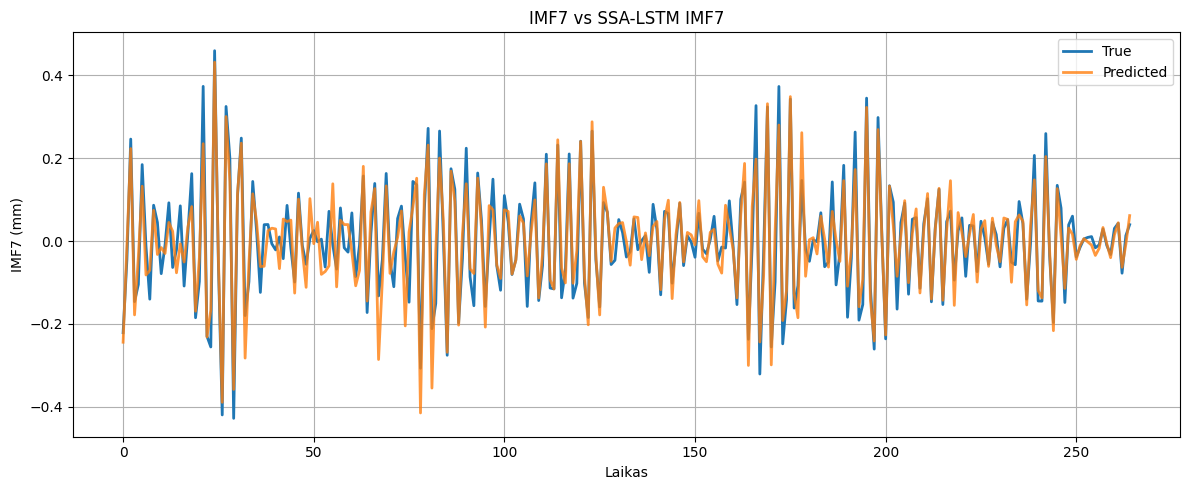

In [517]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True",      linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF7 vs SSA-LSTM IMF7")
plt.xlabel("Laikas")
plt.ylabel("IMF7 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF8

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 14}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 7}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 7}

In [518]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=7,

    module__hidden_dim=256,
    module__num_layers=2,
    module__dropout=0.2,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=0.5),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [519]:
pipeline.fit(X_train_IMF8.values, y_train['IMF8'].values)
pred = pipeline.predict(X_test_IMF8.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0234        0.0239     +  0.5030
      2        0.0147        0.0100     +  0.3318
      3        0.0084        0.0063     +  0.3173
      4        0.0054        0.0049     +  0.3365
      5        0.0047        0.0059        0.3280
      6        0.0040        0.0040     +  0.3285
      7        0.0031        0.0037     +  0.3297
      8        0.0029        0.0034     +  0.3200
      9        0.0029        0.0056        0.3109
     10        0.0043        0.0051        0.3297
     11        0.0033        0.0045        0.3292
     12        0.0027        0.0057        0.3243
     13        0.0027        0.0049        0.3129
     14        0.0026        0.0079        0.2913
     15        0.0032        0.0049        0.2990
     16        0.0028        0.0044        0.2974
     17        0.0026        0.0040        0.3006
     18        0.0028        0.0046        0.3088


In [371]:
param_grid = {
    'window_size': [5, 7],
    'module__hidden_dim': [128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001],
    'module__dropout': [0.2, 0.3],
    'batch_size': [32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF8.values, y_train['IMF8'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF8.values)

Fitting 2 folds for each of 16 candidates, totalling 32 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0500        0.0423     +  0.1337
      2        0.0443        0.0365     +  0.1254
      3        0.0385        0.0307     +  0.1300
      4        0.0309        0.0277     +  0.1104
      5        0.0271        0.0362        0.1013
      6        0.0273        0.0272     +  0.1018
      7        0.0208        0.0239     +  0.0833
      8        0.0162        0.0229     +  0.0938
      9        0.0132        0.0251        0.0847
     10        0.0120        0.0284        0.0834
     11        0.0109        0.0250        0.0969
     12        0.0110        0.0306        0.0858
     13        0.0099        0.0214     +  0.0826
     14        0.0065        0.0181     +  0.0868
     15        0.0051        0.0171     +  0.0859
     16        0.0043        0.0168     +  0.0980
     17        0.0034        0.0179    

In [520]:
y_true = y_test['IMF8'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[7:]
y_pred = np.array(pred).reshape(-1)[:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF8 = y_true[7:]
y_pred_IMF8 = y_pred[7:]

RMSE:     0.0856
MAE:      0.0656
R2:       0.8653
Spearman: 0.9121


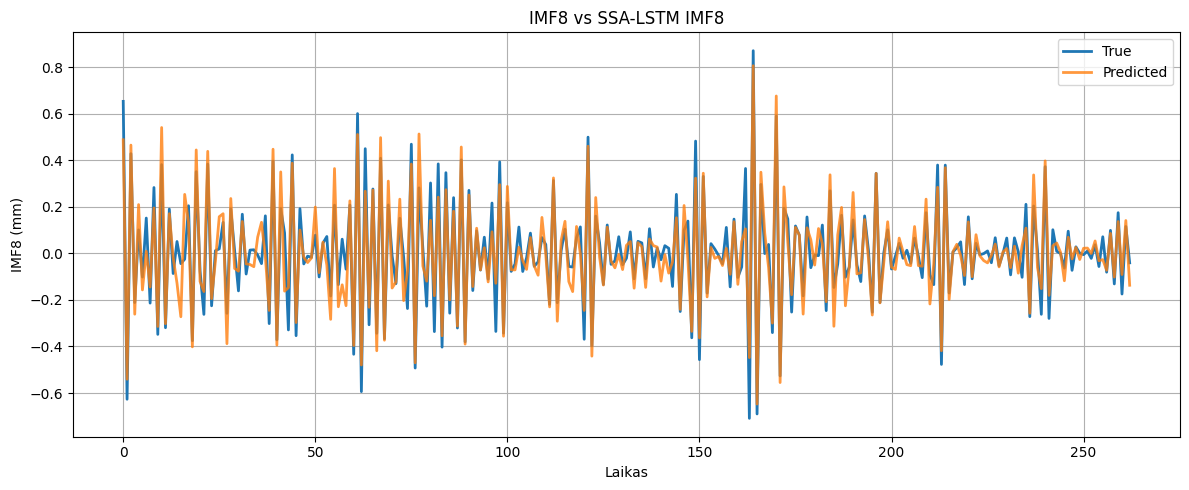

In [521]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True",      linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF8 vs SSA-LSTM IMF8")
plt.xlabel("Laikas")
plt.ylabel("IMF8 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### SSA-LSTM rezultatai

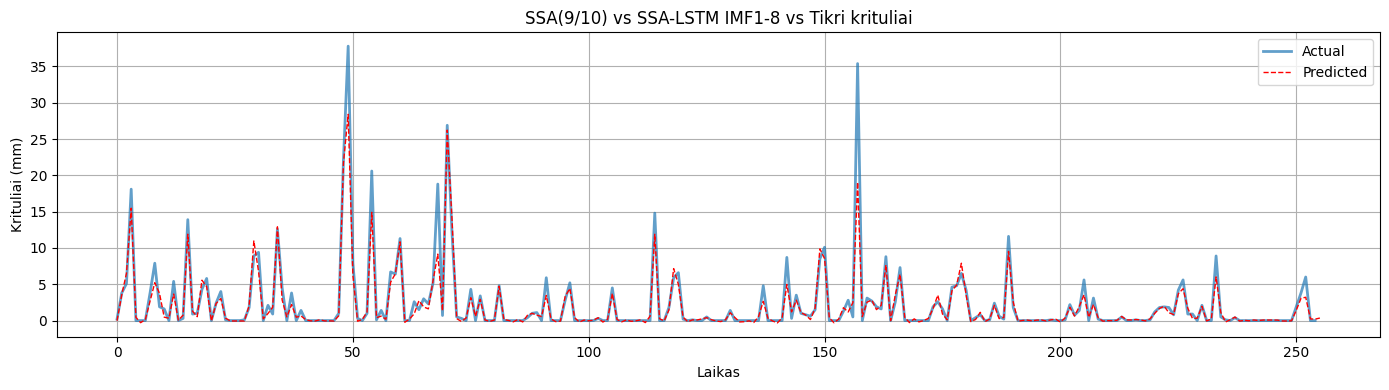

In [541]:
y_true_final = np.expm1(y_true_IMF1[:] + y_true_IMF2[:] + y_true_IMF3[:] + y_true_IMF4[:] + y_true_IMF5 + y_true_IMF6[:] + y_true_IMF7 + y_true_IMF8)
y_pred_final = np.expm1(y_pred_IMF1[:] + y_pred_IMF2[:] + y_pred_IMF3[:] + y_pred_IMF4[:] + y_pred_IMF5 + y_pred_IMF6[:] + y_pred_IMF7 + y_pred_IMF8)
y_actual_precipitation = data['missforest_precipitation'][(int(len(data)*0.9) + 14 + 7):-1].values

plt.figure(figsize=(14, 4))
plt.plot(y_actual_precipitation, label="Actual", linewidth=2, alpha=0.7)
# plt.plot(y_true_final, label="True",      linewidth=1.5, alpha = 0.8)
plt.plot(y_pred_final, label="Predicted", linewidth=1, alpha=1, color='red', linestyle='--')
plt.title("SSA(9/10) vs SSA-LSTM IMF1-8 vs Tikri krituliai")
plt.xlabel("Laikas")
plt.ylabel("Krituliai (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [542]:
rmse = np.sqrt(mean_squared_error(y_true_final, y_pred_final))
mae  = mean_absolute_error(y_true_final, y_pred_final)
r2   = r2_score(y_true_final, y_pred_final)
spearman_corr, _ = spearmanr(y_true_final, y_pred_final)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

RMSE:     0.8578
MAE:      0.3495
R2:       0.9571
Spearman: 0.9698


In [543]:
rmse = np.sqrt(mean_squared_error(y_actual_precipitation, y_pred_final[:-1]))
mae  = mean_absolute_error(y_actual_precipitation, y_pred_final[:-1])
r2   = r2_score(y_actual_precipitation, y_pred_final[:-1])
spearman_corr, _ = spearmanr(y_actual_precipitation, y_pred_final[:-1])

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

RMSE:     1.5947
MAE:      0.6549
R2:       0.8975
Spearman: 0.8872
